# Libraries

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import pickle
from itertools import chain
from pandas import pivot

# Plotting Libs
import matplotlib.pyplot as plt 
import seaborn as sns

# Statistical libs
from scipy import stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

# Scaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

# Load Dfs

In [102]:
df = pd.read_pickle(r".\df_data\df.pkl")
df1 = pd.read_pickle(r".\df_data\df1.pkl")
df2 = pd.read_pickle(r".\df_data\df2.pkl")
df3 = pd.read_pickle(r".\df_data\df3.pkl")
df4 = pd.read_pickle(r".\df_data\df4.pkl")


# Notes
- Must be noted that format Selection is done in this Thesis_Visual_Train file on train set! (Not on Thesis_Visual)
- However, dropping the exluded columns was not done here, as no dfs are saved here, or no dfs from here provide next working files. 
- Thus, the dropping commands displayed here are only for reading convinience in explnatory analysis. 
- Actual dropping columns is done in Thesis_Visual file, due to this is the one that next files take the dfs from.


# Df Input

In [103]:
def fun_res(dfi):

    X = dfi.drop("Study_Status_Bin", axis = 1)
    y = dfi["Study_Status_Bin"]

    X_train_tts, X_test_tts, y_train_tts, y_test_tts = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)
    # Resample needed only for Sparsity in Train set. here All train set can be used.     
    
    X_train_tts = pd.DataFrame(X_train_tts)
    y_train_tts = pd.DataFrame(y_train_tts)
    return X_train_tts, y_train_tts

X_train1, y_train1 = fun_res(df1)
X_train2, y_train2 = fun_res(df2)
X_train3, y_train3 = fun_res(df3)
X_train4, y_train4 = fun_res(df4)

df_train1 = pd.concat([X_train1, y_train1], axis = 1)
df_train2 = pd.concat([X_train2, y_train2], axis = 1)
df_train3 = pd.concat([X_train3, y_train3], axis = 1)
df_train4 = pd.concat([X_train4, y_train4], axis = 1)

In [104]:
i = 1
dfi = df_train1.copy()

In [105]:
dfi.shape

(17463, 53)

# Functions

## chi2_fun

In [106]:
def chi2_fun(col, dfi, i):
    global p_value_chi2
    p_value_chi2 = []
    
    df_plot = dfi[[col, "Study_Status_Bin"]].copy()  
    # df_plot = df_plot.dropna(subset = [col]) All dropped in thesis_Data
    df_plot = df_plot.reset_index(drop = True)
    print(f"df{i}-Phase {i}:\n{col} vs Study Status\n")    

# Descriptives
    df_plot[col] = df_plot[col].astype('category')
    stat = stats.chi2_contingency(pd.crosstab(df_plot[col], df_plot["Study_Status_Bin"]))
    
    pvalue = stat.pvalue
    p_value_chi2.append(pvalue)

# Test
    if pvalue < 0.05 :
        print(f'p-value: {pvalue} < 0.05\n')
    else:
        print(f'p-value: {pvalue} > 0.05 - No significant difference\n')
    print("------------------------------------------------------------------------------------------------------------\n")

    return p_value_chi2

## Logistic

In [107]:
def log_fun(col, dfi, i, type, t, rot, drop_col = None):
    global aic_categ
    global p_value
    global cl
    global pivot
    aic_categ = []
    p_value = []

    print(f"df{i}-Phase {i}:\n{col} vs Study Status (Termination)\n")
    df_plot = dfi[['Study_Status_Bin', col]].copy()
    # df_plot = df_plot.dropna(subset = [col]).reset_index(drop = True)  # All na dropped in Thesis_Data
    df_expl = df_plot.explode(col) # Do not reset index, needed for groupby
    df_expl[col] = pd.Categorical(df_expl[col], ordered = t)
    df_expl[col] = df_expl[col].cat.remove_unused_categories()

    # Pivot Table
    pivot = df_expl.pivot_table(
        index = [col], 
        columns = ["Study_Status_Bin"], 
        aggfunc = "size", 
        fill_value = 0, 
        observed = False)
    
    pivot.index = pd.MultiIndex.from_tuples(
        [(col, val) for val in pivot.index])
    
    display(pivot)

    if (pivot <= 5).any().any():
        print("SPARSITY RISK\n")

    # Dummies - df_model      
    if type == 'list':    
        dummies = pd.get_dummies(df_expl[col] , drop_first = False, dtype = int , prefix = '' , prefix_sep = '', dummy_na = False)
        dummies.index = df_expl.index # ensure same index dummies - df_expl --> same index dummies.grouped - df_plot (= melted df_expl)
        dummies = dummies.groupby(dummies.index).sum()   # index needed for groupby comes from dummies not exploded df_plot
        df_model = pd.concat([df_plot.drop(columns = [col], axis = 1), dummies], axis=1)
        if drop_col != None:
            df_model = df_model.drop(columns = [drop_col], axis = 1)
    else:
        df_model = df_expl.copy()
        cats = sorted(dfi[col].dropna().unique())
        df_model[col] = df_model[col].map({cats[0]: 0, cats[1]: 1, 'No':0, 'Yes':1})
                
    # Model
    X = sm.add_constant(df_model.drop(columns = ["Study_Status_Bin"], axis = 1))
    y = (df_model["Study_Status_Bin"] == "TERMINATED").astype(int)

    model = sm.Logit(y, X)
    results = model.fit(method = 'lbfgs', maxiter = 500)
    print(results.summary())
    print("\n")

    # AIC
    aic = round(results.aic, 0)  # AIC test in case needed for comparison
    aic_categ.append(aic)
    pvalue = results.pvalues
    p_value.append(pvalue)
    cl = results.conf_int()
    
    print(f'df{i}-Phase{i}: {col} p-values:\n{p_value}\n')
    print(f'df{i}-Phase{i}: {col} AIC:\n{aic}')  
    print("\n------------------------------------------------------------------------------------------------------------\n")

    # df_plot
    df_plot = df_plot.explode(col)# .reset_index(drop = True)
    df_plot[col] = pd.Categorical(df_plot[col], ordered = t)
    df_plot[col] = df_plot[col].cat.remove_unused_categories()
    
    # Plot
    plt.figure(figsize = (10, 2))
    sns.countplot(data = df_plot, x = col, hue = 'Study_Status_Bin')
    plt.xticks(rotation = rot, fontsize = 8) 
    plt.legend(bbox_to_anchor = (1.05, 1), loc = 2)
    plt.title(f"df{i}-Phase{i}: {col} vs Study Status", pad = 20)
    plt.xlabel(xlabel = col, labelpad = 10)

    return aic_categ, p_value, cl, pivot

## Log_fun_cont

In [108]:
def log_fun_cont(col, dfi, i):
    global aic_cont
    global p_value
    global cl
    aic_cont = []
    p_value = []

    df_plot = dfi.copy()
    # df_plot = df_plot.dropna(subset = [col]).reset_index(drop = True) # all dropped in Thesis_Data file
    df_plot_y = dfi[["Study_Status_Bin"]].copy()
    df_plot_x = dfi[[col]].copy()

# Dfi names
    print(f"df{i}-Phase {i}:\n{col} vs Study Status")
    print("\n")
    
# Descriptives
    print(df_plot[col].describe())
    print("\n")

# Scale
    scaler = MinMaxScaler()
    data_scaled_x = scaler.fit_transform(df_plot_x)
    df_scaled_x = pd.DataFrame(data_scaled_x, index = df_plot_x.index)
    df_scaled = pd.concat([df_plot_y, df_scaled_x], axis=1)
    df_scaled.rename(columns={0: col}, inplace=True)

    X = sm.add_constant(df_scaled[col])
    y = (df_scaled["Study_Status_Bin"] == "TERMINATED").astype(int)

# Model
    model = sm.Logit(y, X)
    results = model.fit(method='lbfgs', maxiter = 500)
    print(results.summary())
    print("\n")

# AIC
    aic = round(results.aic, 0)
    aic_cont.append(aic)
    pvalue = results.pvalues
    p_value.append(pvalue)
    cl = results.conf_int()
    
    print(f'df{i}-Phase{i}, {col} p-values:\n{p_value}\n')
    print(f'df{i}-Phase{i}, {col} AIC:\n{aic}')
    print("\n------------------------------------------------------------------------------------------------------------\n")

# Plot
    fig , ax = plt.subplots(figsize = (20, 4) , ncols = 2, nrows = 1, layout = 'tight')
    color = sns.color_palette("tab10", n_colors = 2)
    
    sns.boxplot(x = col, hue = "Study_Status_Bin", data = dfi, ax = ax[0] , legend = True) 
    sns.kdeplot(x = col, hue = "Study_Status_Bin", data = dfi, ax = ax[1] , legend = False) 

    ax[0].legend(bbox_to_anchor = (1.05, 1), loc = 2)
    
    return aic_cont, p_value, cl

## Compare

In [109]:
def fun_compare(i, **args):

    AIC_Min = pd.DataFrame([args], index = [f'{list(args.keys())[0]}'])  
    AIC_Min['AIC_min'] = AIC_Min.idxmin(axis = 1)
    AIC_Min.index.name = f'df{i}'
    return AIC_Min

# Visualization

## Phases_List
All df before Seperation into Phases

df-Phase :
Phases_List vs Study Status (Termination)



Study_Status_Bin    COMPLETED  TERMINATED
Phases_List PHASE1      18646        3183
            PHASE2      15804        5424
            PHASE3      11557        2409
            PHASE4      10937        2309

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                70269
Model:                          Logit   Df Residuals:                    70265
Method:                           MLE   Df Model:                            3
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                 0.01309
Time:                        04:50:47   Log-Likelihood:                -33682.
converged:                       True   LL-Null:                       -34129.
Covariance Type:            nonrobust   LLR p-value:                2.022e-193
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.7678      0.019    -92.178      0.000      -1.805      -1.730
PHASE2         0.6983      0.025     28.150      0.000       0.650       0.747
PHASE3         0.1997      0.029      6.772      0.0

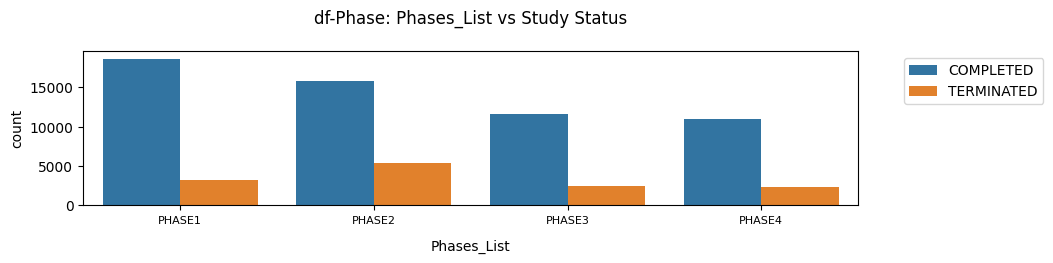

In [110]:
Phases_List = log_fun('Phases_List', df, '', 'list', False, 0, 'PHASE1')

## Adverse


### Adverse_List

df1-Phase 1:
Adverse_List vs Study Status (Termination)



Study_Status_Bin              COMPLETED  TERMINATED
Adverse_List Adv_Death             1118         213
             Adv_None             12446        2153
             Adv_Serious            934         243
             Adv_Unspecified       2386         379

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17459
Method:                           MLE   Df Model:                            3
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                0.005550
Time:                        04:50:48   Log-Likelihood:                -7212.9
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 2.386e-17
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -1.7573      0.023    -75.482      0.000      -1.803      -1.712
Adv_Death           0.0249      0.110      0.226      0.821      -0.191       0.241
Adv_Serious         0.9554      

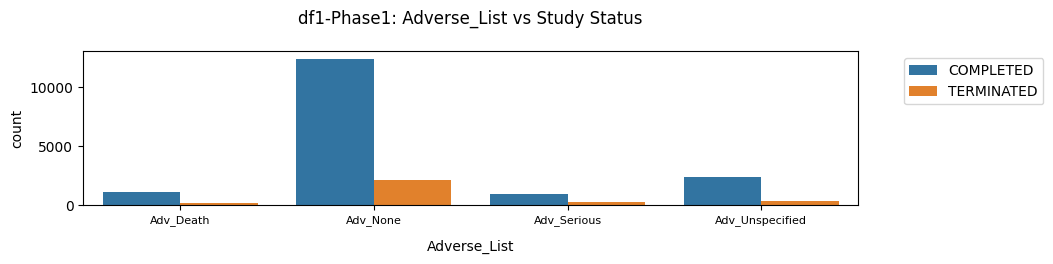

In [111]:
Adverse_List = log_fun("Adverse_List", dfi, i, 'list', False, 0, 'Adv_None')
# Adverse Death has p value >> 0.05 
# Death does not support adverse from the drug/intervention.
# Corresponds to event noticed in trial but may correspond to patients' state of health due to condition

### Adverse_Counts
Many unique points, in most of features values, are out of main distribution. --> Make pd.cut
log_fun('Adverse_Counts', dfi, i, 'bin', True, 0) --> Error for small values in some levels


df1-Phase 1:
Adverse_Counts vs Study Status


count    17463.000000
mean         5.243200
std         43.619651
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       3385.000000
Name: Adverse_Counts, dtype: float64


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:               0.0008342
Time:                        04:50:49   Log-Likelihood:                -7247.1
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 0.0005038
                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------

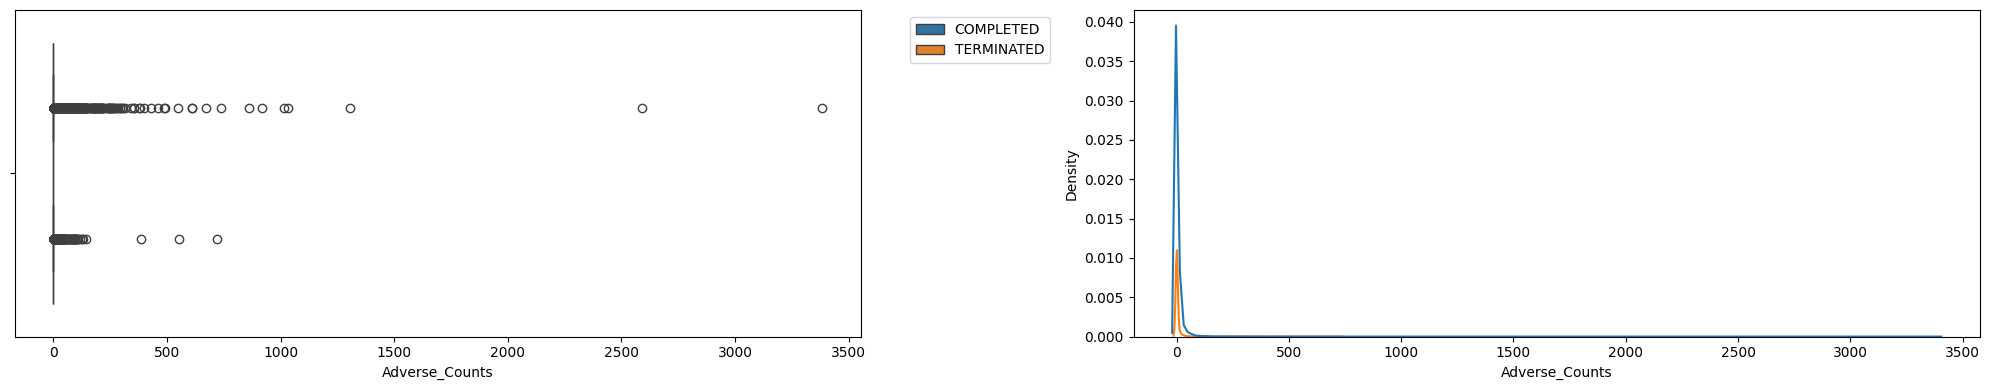

In [112]:
Adverse_Counts = log_fun_cont("Adverse_Counts", dfi, i)  

### Adverse_Counts_Log
- Adverse_Counts despite mostly have the ditribution around small values (0,1,2 etc.) they also have a wide range of values in the remaining distribution.
- That is why they were checked as Log too

df1-Phase 1:
Adverse_Counts_Log vs Study Status


count    17463.000000
mean         0.443435
std          1.106788
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          8.127405
Name: Adverse_Counts_Log, dtype: float64


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:               0.0009463
Time:                        04:50:50   Log-Likelihood:                -7246.3
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 0.0002113
                         coef    std err          z      P>|z|      [0.025      0.975]
------------

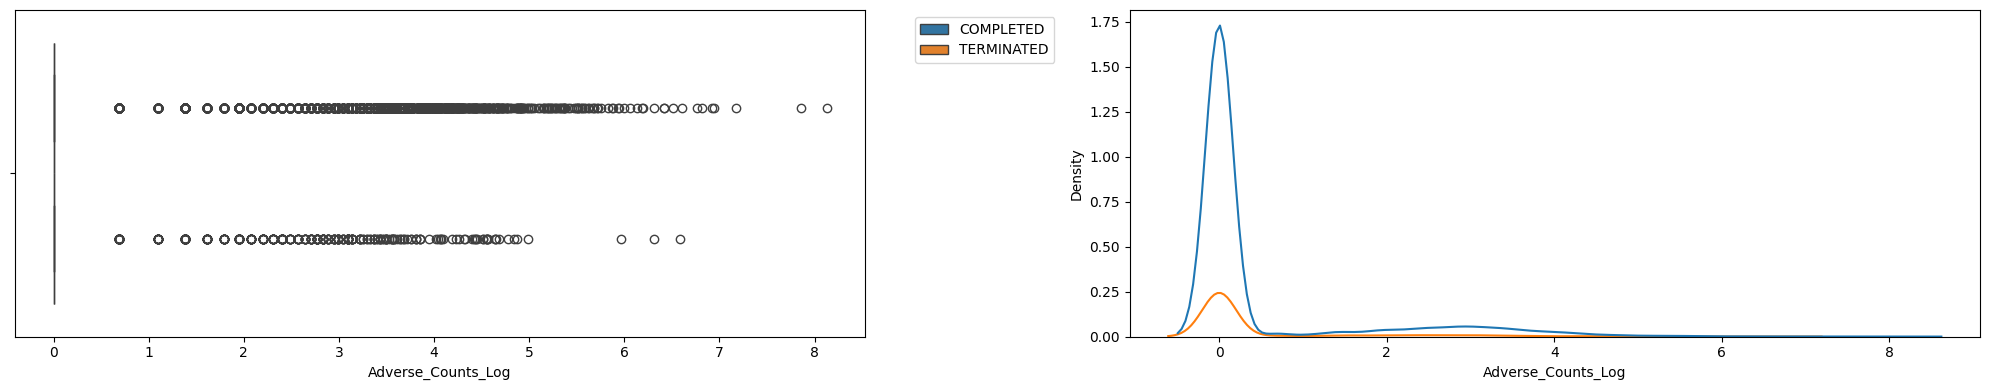

In [113]:
Adverse_Counts_Log = log_fun_cont("Adverse_Counts_Log", dfi, i)

### Adverse_Bin

df1-Phase 1:
Adverse_Bin vs Study Status

p-value: 0.1925865561340007 > 0.05 - No significant difference

------------------------------------------------------------------------------------------------------------

df1-Phase 1:
Adverse_Bin vs Study Status (Termination)



Study_Status_Bin         COMPLETED  TERMINATED
Adverse_Bin Adverse_No       12505        2161
            Adverse_Yes       2412         385

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:               0.0001239
Time:                        04:50:51   Log-Likelihood:                -7252.2
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                    0.1800
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -1.7556      0.023    -75.358      0.000      -1.801      -1.710
Adverse_Bin    -0.0794      0.060     -1.331      0.183      -0.196       0.037


df1-Phase1: Adverse_Bin p-values:
[const      

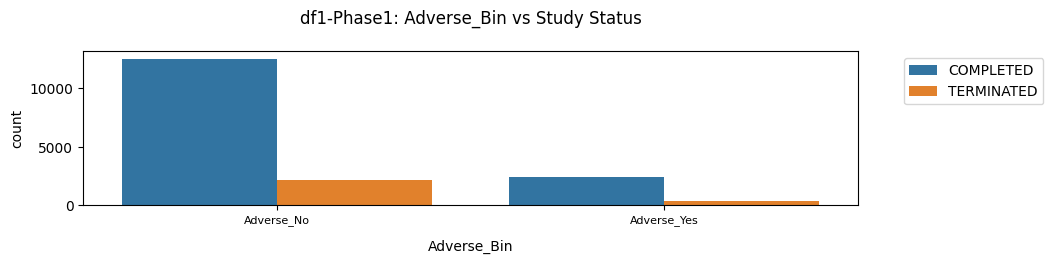

In [114]:
chi2_fun('Adverse_Bin', dfi, i)
#### log_fun
Adverse_Bin = log_fun("Adverse_Bin", dfi, i, 'bin', False, 0)

#### Format
- Risk of sparsity with categ
- Drop _Bin anyway as with the continues variable the question is answered.

In [115]:
Adverse_Counts_aic = fun_compare(i, Adverse_Counts = Adverse_Counts[0], 
                                 Adverse_Counts_Log = Adverse_Counts_Log[0], 
                                 Adverse_Bin = Adverse_Bin[0])
Adverse_Counts_aic

,Adverse_Counts,Adverse_Counts_Log,Adverse_Bin,AIC_min
df1,,,,
Adverse_Counts,[14498.0],[14497.0],[14508.0],Adverse_Counts_Log


In [116]:
#dfi = dfi.drop(columns = ['Adverse_Counts', 'Adverse_Bin'], axis = 1)  

### Adverse_System_List


df1-Phase 1:
Adverse_System_List vs Study Status (Termination)



Study_Status_Bin                                              COMPLETED  \
Adverse_System_List Adv_Syst_Blood, Lymphatic, Endocrine            843   
                    Adv_Syst_Cardio                                 789   
                    Adv_Syst_Ear                                    480   
                    Adv_Syst_Eye                                    802   
                    Adv_Syst_Gastrointestinal                      1968   
                    Adv_Syst_General                               1792   
                    Adv_Syst_Hepatobiliary                          352   
                    Adv_Syst_Immune System                          372   
                    Adv_Syst_Infections                            1538   
                    Adv_Syst_Injury, Poisoning, Procedural         1142   
                    Adv_Syst_Metabolism/ Nutrition                  901   
                    Adv_Syst_Musculoskeletal                       1502   
                    Adv_Syst_Neoplasms                              377   
                    Adv_Syst_Nervous System                        1971   
                    Adv_Syst_None                                 12444   
                    Adv_Syst_Product Issues, Investigations        1143   
                    Adv_Syst_Psychiatric, Social                    881   
                    Adv_Syst_Renal, Urinary                         763   
                    Adv_Syst_Reproductive, Pregnancy, Breast        541   
                    Adv_Syst_Respiratory                           1420   
                    Adv_Syst_Skin                                  1408   
                    Adv_Syst_Surgical, Medical                      113   
                    Adv_Syst_Vascular                               868   

Study_Status_Bin                                              TERMINATED  
Adverse_System_List Adv_Syst_Blood, Lymphatic, Endocrine             225  
                    Adv_Syst_Cardio                                  194  
                    Adv_Syst_Ear                                      91  
                    Adv_Syst_Eye                                     157  
                    Adv_Syst_Gastrointestinal                        325  
                    Adv_Syst_General                                 321  
                    Adv_Syst_Hepatobiliary                            93  
                    Adv_Syst_Immune System                            87  
                    Adv_Syst_Infections                              268  
                    Adv_Syst_Injury, Poisoning, Procedural           202  
                    Adv_Syst_Metabolism/ Nutrition                   244  
                    Adv_Syst_Musculoskeletal                         261  
                    Adv_Syst_Neoplasms                               114  
                    Adv_Syst_Nervous System                          313  
                    Adv_Syst_None                                   2153  
                    Adv_Syst_Product Issues, Investigations          261  
                    Adv_Syst_Psychiatric, Social                     200  
                    Adv_Syst_Renal, Urinary                          193  
                    Adv_Syst_Reproductive, Pregnancy, Breast          97  
                    Adv_Syst_Respiratory                             260  
                    Adv_Syst_Skin                                    264  
                    Adv_Syst_Surgical, Medical                        22  
                    Adv_Syst_Vascular                                213

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17440
Method:                           MLE   Df Model:                           22
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                 0.01141
Time:                        04:50:52   Log-Likelihood:                -7170.4
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 5.291e-24
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
const                                       -1.7625      0.023    -76.213      0.000      -1.808      -1.717
Adv_Syst_Blood, Lymphatic, Endocrine     

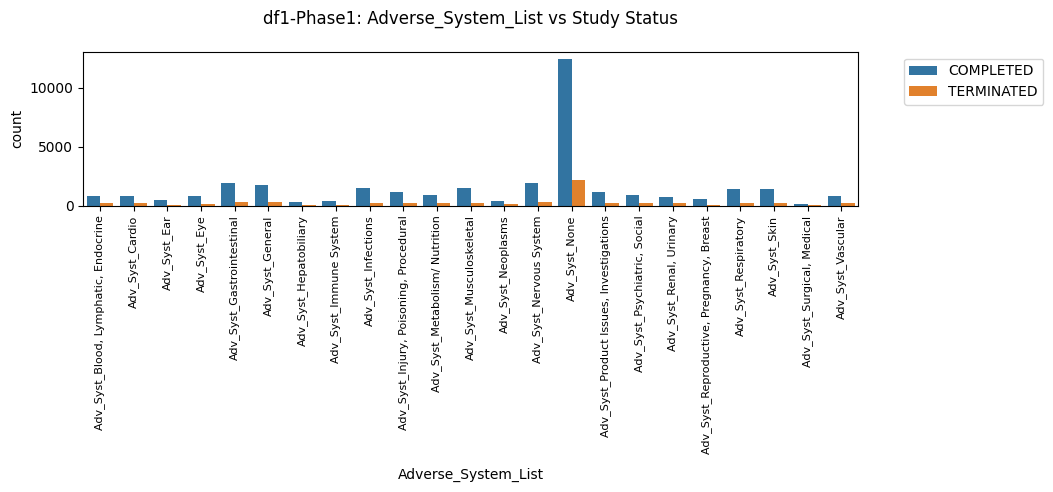

In [117]:
Adverse_System_List = log_fun("Adverse_System_List", dfi, i, 'list', False, 90, 'Adv_Syst_None')

### Adverse_System_Counts
- Different from Adverse_Counts: 
Adverse_Counts = Count of events category (e.g 100 serioues)
Adverse_System_Counts = How many organs.


df1-Phase 1:
Adverse_System_Counts vs Study Status


count    17463.000000
mean         1.510107
std          4.180349
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         22.000000
Name: Adverse_System_Counts, dtype: float64


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:               0.0005464
Time:                        04:50:53   Log-Likelihood:                -7249.2
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                  0.004874
                            coef    std err          z      P>|z|      [0.025      0.975]
---

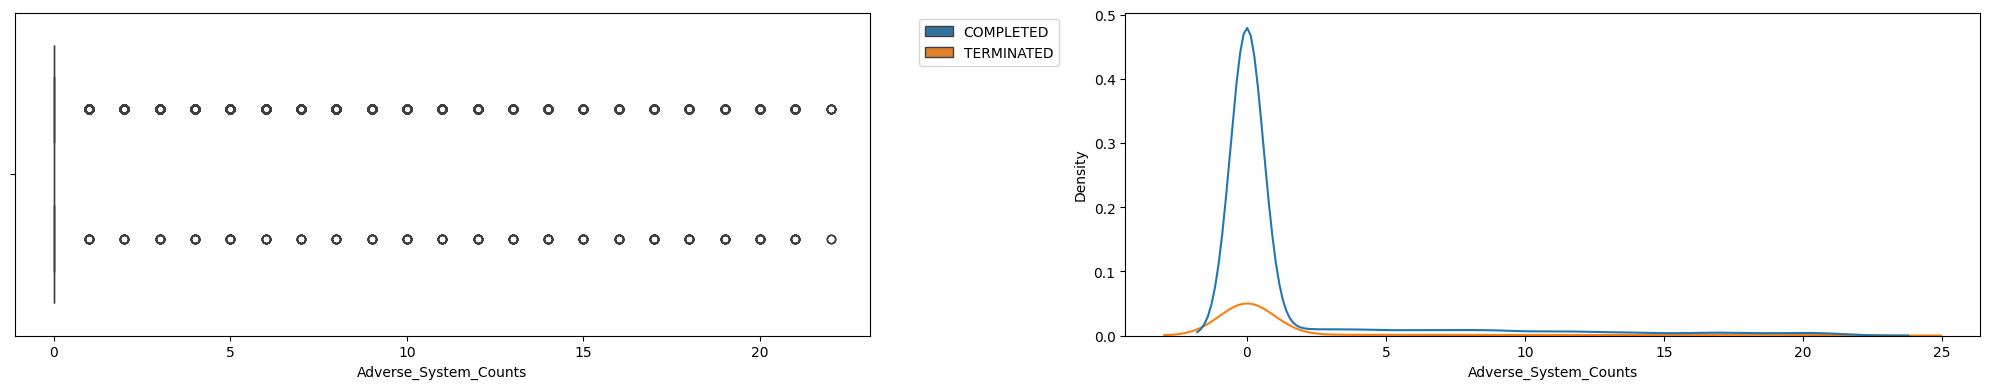

In [118]:
Adverse_System_Counts = log_fun_cont("Adverse_System_Counts", dfi, i)

### Adverse_System_Counts_Log
- Adverse_System_Counts despite mostly have the ditribution around small values (0,1,2 etc.) they also have a wide range of values in the remaining distribution.
- That is why they were checked as Log too

df1-Phase 1:
Adverse_System_Counts_Log vs Study Status


count    17463.000000
mean         0.346137
std          0.831625
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.135494
Name: Adverse_System_Counts_Log, dtype: float64


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:               2.631e-05
Time:                        04:50:54   Log-Likelihood:                -7253.0
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                    0.5367
                                coef    std err          z      P>|z|      [0.025    

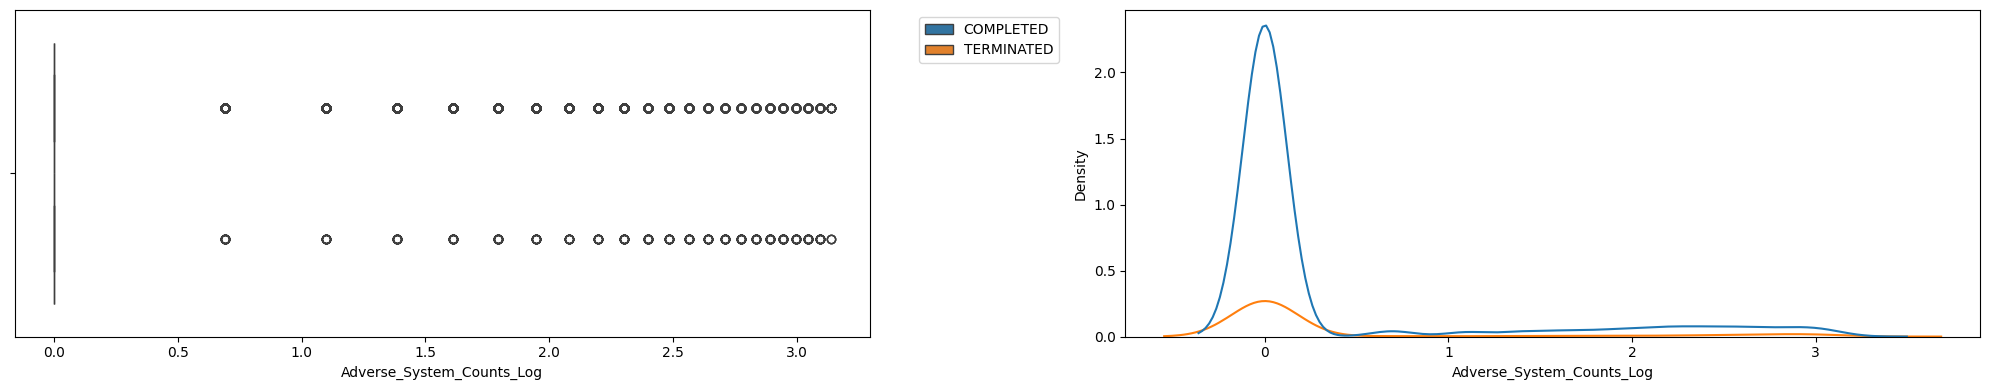

In [119]:
Adverse_System_Counts_Log = log_fun_cont("Adverse_System_Counts_Log", dfi, i)

### Adverse_System_Categ

df1-Phase 1:
Adverse_System_Categ vs Study Status

p-value: 0.34805869750755847 > 0.05 - No significant difference

------------------------------------------------------------------------------------------------------------

df1-Phase 1:
Adverse_System_Categ vs Study Status (Termination)



Study_Status_Bin           COMPLETED  TERMINATED
Adverse_System_Categ 0–1       12656        2179
                     2–22       2261         367

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:               6.527e-05
Time:                        04:50:55   Log-Likelihood:                -7252.7
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                    0.3305
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -1.7593      0.023    -75.852      0.000      -1.805      -1.714
Adverse_System_Categ    -0.0589      0.061     -0.968      0.333      -0.178       0.060


df1-Phase1

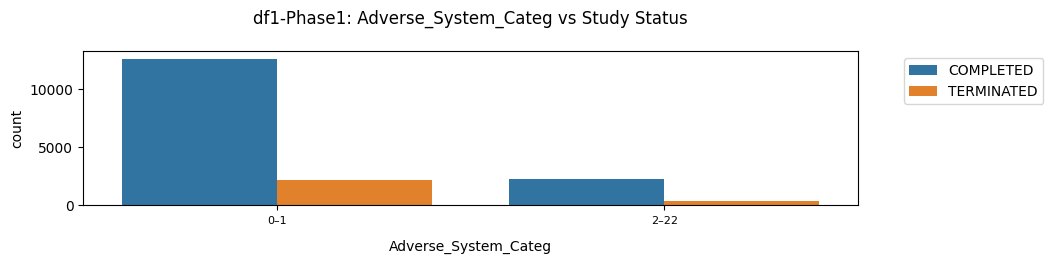

In [120]:
chi2_fun('Adverse_System_Categ', dfi, i)

#### log_fun
Adverse_System_Categ = log_fun('Adverse_System_Categ', dfi, i, 'bin', True, 0)


In [121]:
# #dfi = dfi.drop(columns = ['Adverse_Counts', 'Adverse_Bin'], axis = 1)

#### Format
- Risk of Sparsity with Categ
- Similar information with Adverse_Counts

In [122]:
Adverse_System_Counts_aic = fun_compare(i, 
                                        Adverse_System_Counts = Adverse_System_Counts[0], 
                                        Adverse_System_Counts_Log = Adverse_System_Counts_Log[0],
                                        ) 
Adverse_System_Counts_aic

,Adverse_System_Counts,Adverse_System_Counts_Log,AIC_min
df1,,,
Adverse_System_Counts,[14502.0],[14510.0],Adverse_System_Counts


In [123]:
Adverse_aic = fun_compare(i, Adverse_List = Adverse_List[0],
                          Adverse_System_List = Adverse_System_List[0],
                                        ) 
Adverse_aic

,Adverse_List,Adverse_System_List,AIC_min
df1,,,
Adverse_List,[14434.0],[14387.0],Adverse_System_List


In [124]:
#dfi = dfi.drop(columns = ['Adverse_System_Counts', 'Adverse_System_Categ'], axis = 1)

## Placebo_Bin

df1-Phase 1:
Placebo_Bin vs Study Status

p-value: 5.584977046742027e-10 < 0.05

------------------------------------------------------------------------------------------------------------

df1-Phase 1:
Placebo_Bin vs Study Status (Termination)



Study_Status_Bin         COMPLETED  TERMINATED
Placebo_Bin Placebo_No       11824        2154
            Placebo_Yes       3093         392

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                0.002820
Time:                        04:50:55   Log-Likelihood:                -7232.7
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 1.596e-10
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -1.7028      0.023    -72.686      0.000      -1.749      -1.657
Placebo_Bin    -0.3628      0.059     -6.201      0.000      -0.478      -0.248


df1-Phase1: Placebo_Bin p-values:
[const      

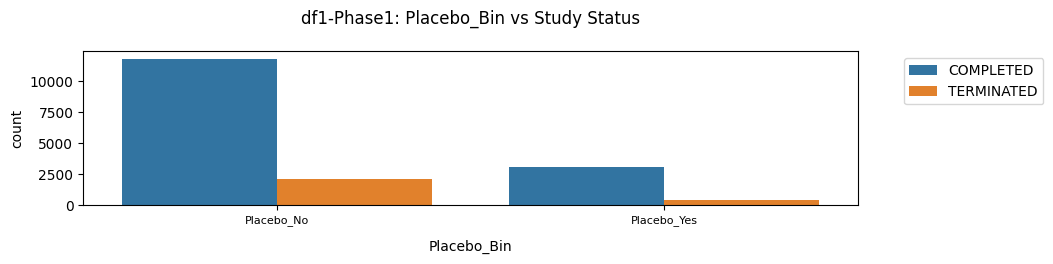

In [125]:
chi2_fun("Placebo_Bin", dfi, i)
### log_fun
Placebo_Bin = log_fun('Placebo_Bin', dfi, i, 'bin', False, 0)

## Standard_Care_Bin 

df1-Phase 1:
Standard_Care_Bin vs Study Status

p-value: 4.2027665721232615e-20 < 0.05

------------------------------------------------------------------------------------------------------------

df1-Phase 1:
Standard_Care_Bin vs Study Status (Termination)



Study_Status_Bin           COMPLETED  TERMINATED
Standard_Care_Bin Soc_No       14745        2455
                  Soc_Yes        172          91

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                0.004600
Time:                        04:50:56   Log-Likelihood:                -7219.8
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 3.123e-16
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.7928      0.022    -82.245      0.000      -1.836      -1.750
Standard_Care_Bin     1.1562      0.131      8.796      0.000       0.899       1.414


df1-Phase1: Standard_C

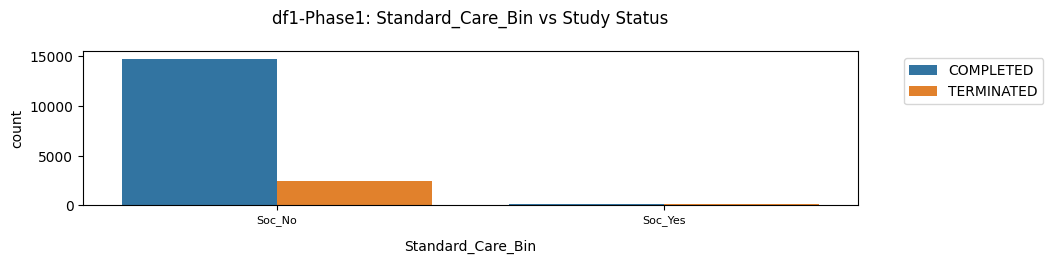

In [126]:
chi2_fun("Standard_Care_Bin", dfi, i)
### log_fun
Standard_Care_Bin = log_fun('Standard_Care_Bin', dfi, i, 'bin', False, 0)

## Healthy_Bin

df1-Phase 1:
Healthy_Bin vs Study Status

p-value: 1.7212498411218487e-286 < 0.05

------------------------------------------------------------------------------------------------------------

df1-Phase 1:
Healthy_Bin vs Study Status (Termination)



Study_Status_Bin          COMPLETED  TERMINATED
Healthy_Bin Healthy_No         5603        1935
            _Healthy_Yes       9314         611

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                 0.09163
Time:                        04:50:56   Log-Likelihood:                -6588.6
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                5.166e-291
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -1.0632      0.026    -40.322      0.000      -1.115      -1.012
Healthy_Bin    -1.6607      0.049    -33.628      0.000      -1.758      -1.564


df1-Phase1: Healthy_Bin p-values:
[const      

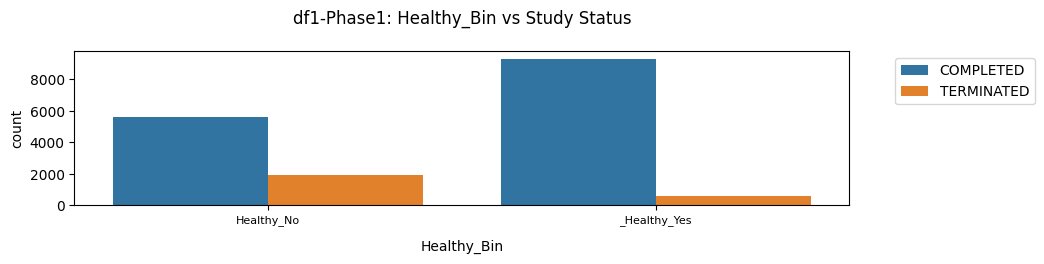

In [127]:
chi2_fun("Healthy_Bin", dfi, i)
### log_fun
Healthy_Bin = log_fun('Healthy_Bin', dfi, i, 'bin', False, 0)

## Covid_19_Bin

df1-Phase 1:
Covid_19_Bin vs Study Status

p-value: 0.0005067952714062783 < 0.05

------------------------------------------------------------------------------------------------------------

df1-Phase 1:
Covid_19_Bin vs Study Status (Termination)



Study_Status_Bin        COMPLETED  TERMINATED
Covid_19_Bin Covid_No       14733        2492
             Covid_Yes        184          54

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:               0.0007742
Time:                        04:50:57   Log-Likelihood:                -7247.5
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 0.0008045
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -1.7770      0.022    -82.041      0.000      -1.819      -1.735
Covid_19_Bin     0.5511      0.156      3.526      0.000       0.245       0.857


df1-Phase1: Covid_19_Bin p-values:
[const 

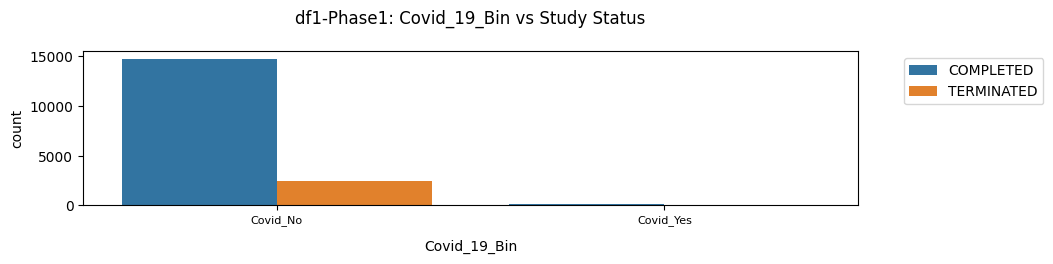

In [128]:
chi2_fun("Covid_19_Bin", dfi, i)
### log_fun
Covid_19_Bin = log_fun('Covid_19_Bin', dfi, i, 'bin', False, 0)

### Format
- Similar information with Respiratory Conditions_Detail

In [129]:
#dfi = dfi.drop(columns = ['Covid_19_Bin'])

## Conditions_Detail_List

df1-Phase 1:
Conditions_Detail_List vs Study Status (Termination)



Study_Status_Bin                                                        COMPLETED  \
Conditions_Detail_List Bacterial, Mycoses, Virus Diseases                    1867   
                       Cardiovascular                                         774   
                       Cond_Detail_Other                                     4291   
                       Digestive System, Nutritional, Metabolic              2503   
                       Endocrine System                                      1097   
                       Eye                                                    193   
                       Health Care, Therapeutics                              224   
                       Hemic, Lymphatic, Immune System                       1846   
                       Hereditary, Neonatal, Abnormalities                    566   
                       Musculoskeletal, Neural                                658   
                       Neoplasms                                             3181   
                       Nervous System                                        1273   
                       Pathological Conditions, Signs, Symptoms              1989   
                       Phenomena, Processes                                   507   
                       Psychiatry, Psychology, Anthropology, Sociology       1190   
                       Respiratory, Circulatory                              1447   
                       Skin, Tissue, Wounds                                  1445   
                       Stomatognathic, Otorhinolaryngologic                   172   
                       Urogenital, Pregnancy                                 1182   

Study_Status_Bin                                                        TERMINATED  
Conditions_Detail_List Bacterial, Mycoses, Virus Diseases                      243  
                       Cardiovascular                                          177  
                       Cond_Detail_Other                                       232  
                       Digestive System, Nutritional, Metabolic                452  
                       Endocrine System                                        199  
                       Eye                                                      33  
                       Health Care, Therapeutics                                16  
                       Hemic, Lymphatic, Immune System                         586  
                       Hereditary, Neonatal, Abnormalities                      93  
                       Musculoskeletal, Neural                                  82  
                       Neoplasms                                              1357  
                       Nervous System                                          237  
                       Pathological Conditions, Signs, Symptoms                472  
                       Phenomena, Processes                                     55  
                       Psychiatry, Psychology, Anthropology, Sociology         169  
                       Respiratory, Circulatory                                326  
                       Skin, Tissue, Wounds                                    391  
                       Stomatognathic, Otorhinolaryngologic                     31  
                       Urogenital, Pregnancy                                   278

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17444
Method:                           MLE   Df Model:                           18
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                 0.08321
Time:                        04:50:57   Log-Likelihood:                -6649.6
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                3.395e-245
                                                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------
const                                              -2.5582      0.042    -60.383      0.000      -2.641      -2.475
Bacterial, Mycoses, 

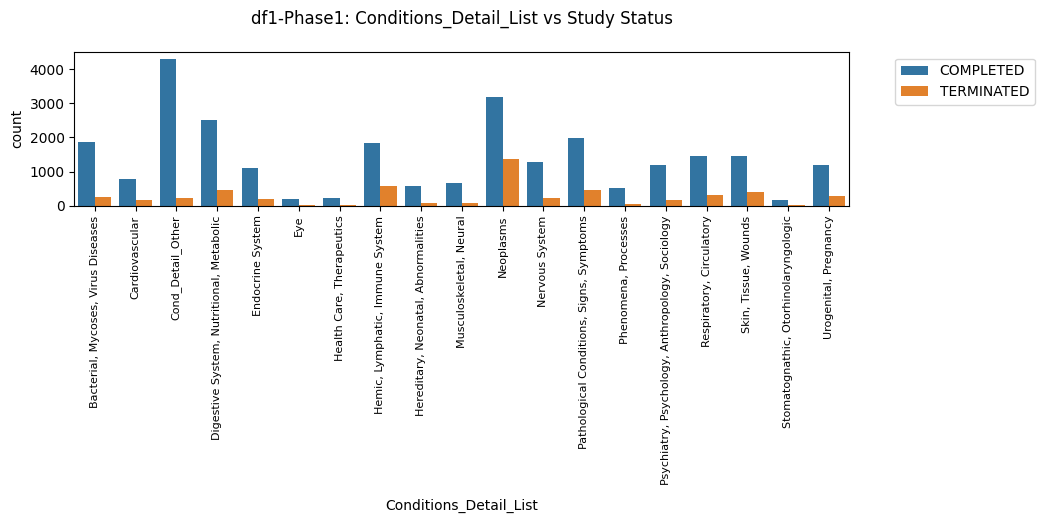

In [ ]:
Conditions_Detail_List = log_fun("Conditions_Detail_List", dfi, i, 'list', False, 90, 'Health Care, Therapeutics, Cond_Detail_Other' )

## Funder_Industry_Bin

df1-Phase 1:
Funder_Industry_Bin vs Study Status (Termination)



Study_Status_Bin                  COMPLETED  TERMINATED
Funder_Industry_Bin FUNDER_OTHER       3989        1104
                    INDUSTRY          10928        1442

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                 0.01887
Time:                        04:50:58   Log-Likelihood:                -7116.2
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 1.688e-61
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -1.2847      0.034    -37.777      0.000      -1.351      -1.218
Funder_Industry_Bin    -0.7406      0.044    -16.807      0.000      -0.827      -0.654


df1-Phase1: Fu

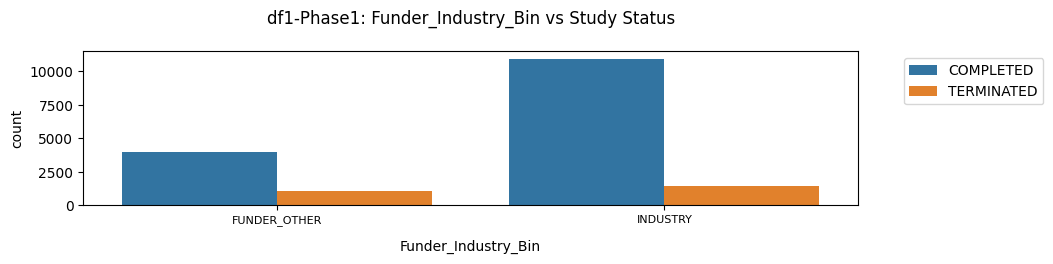

In [131]:
Funder_Industry_Bin = log_fun("Funder_Industry_Bin", dfi, i, 'bin', False, 0, 'FUNDER_OTHER')

## Funder_Counts

df1-Phase 1:
Funder_Counts vs Study Status


count    17463.000000
mean         1.359102
std          0.760340
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         15.000000
Name: Funder_Counts, dtype: float64


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:               0.0009426
Time:                        04:50:58   Log-Likelihood:                -7246.3
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 0.0002175
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------

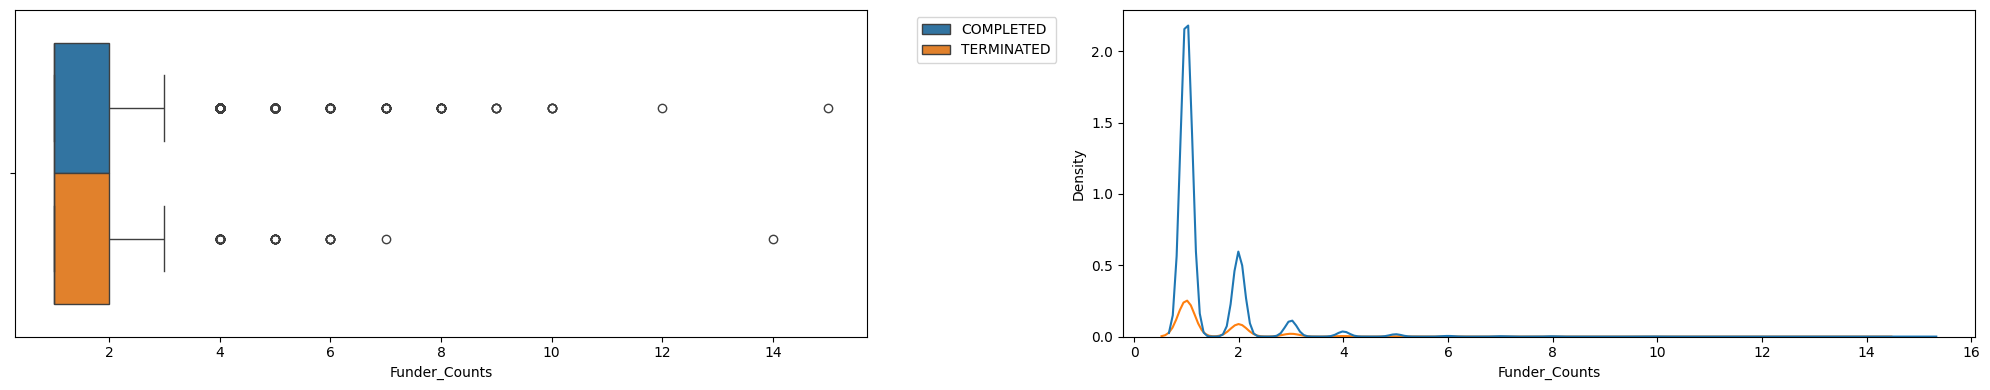

In [132]:
Funder_Counts = log_fun_cont("Funder_Counts", dfi, i)

## Funder_Counts_Log

df1-Phase 1:
Funder_Counts_Log vs Study Status


count    17463.000000
mean         0.823637
std          0.241760
min          0.693147
25%          0.693147
50%          0.693147
75%          1.098612
max          2.772589
Name: Funder_Counts_Log, dtype: float64


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                0.001590
Time:                        04:50:59   Log-Likelihood:                -7241.6
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 1.572e-06
                        coef    std err          z      P>|z|      [0.025      0.975]
---------------

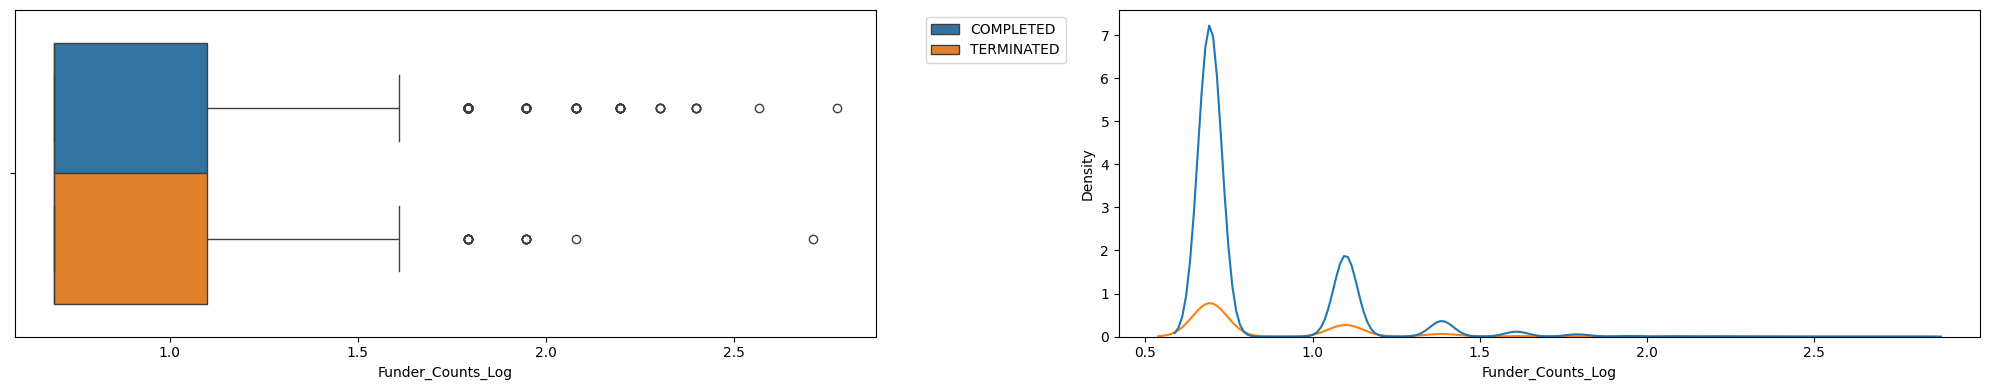

In [133]:
Funder_Counts_Log = log_fun_cont("Funder_Counts_Log", dfi, i)

### Format

In [134]:
Funder_Counts = fun_compare(i, Funder_Counts = Funder_Counts[0], 
                            Funder_Counts_Log = Funder_Counts_Log[0]) 
Funder_Counts

,Funder_Counts,Funder_Counts_Log,AIC_min
df1,,,
Funder_Counts,[14497.0],[14487.0],Funder_Counts_Log


In [135]:
#dfi = dfi.drop(columns = ['Funder_Counts'], axis = 1)

## Age_List

df1-Phase 1:
Age_List vs Study Status (Termination)



Study_Status_Bin      COMPLETED  TERMINATED
Age_List ADULT            14560        2462
         CHILD              810         213
         OLDER_ADULT       7445        1975

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17460
Method:                           MLE   Df Model:                            2
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                 0.05220
Time:                        04:51:00   Log-Likelihood:                -6874.5
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                3.676e-165
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -1.6807      0.125    -13.473      0.000      -1.925      -1.436
ADULT          -0.9577      0.129     -7.407      0.000      -1.211      -0.704
OLDER_ADULT     1.3040      0.052     25.268    

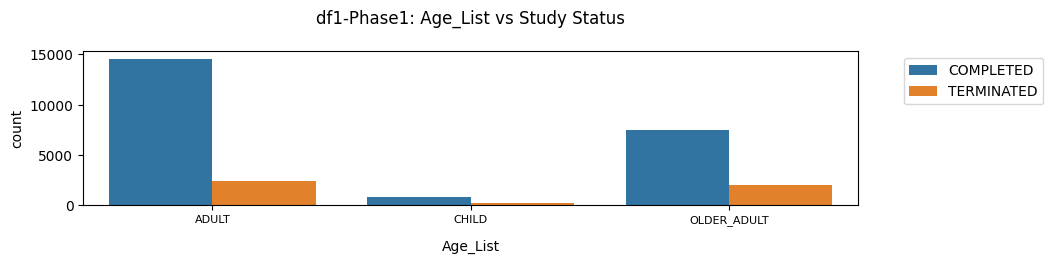

In [136]:
Age_List = log_fun("Age_List", dfi, i, 'list', False, 0, 'CHILD')

## Sex_List


df1-Phase 1:
Sex_List vs Study Status (Termination)



Study_Status_Bin  COMPLETED  TERMINATED
Sex_List ALL          12088        2255
         FEMALE         588         133
         MALE          2241         158

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17460
Method:                           MLE   Df Model:                            2
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                 0.01190
Time:                        04:51:01   Log-Likelihood:                -7166.8
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 3.250e-38
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.6791      0.023    -73.198      0.000      -1.724      -1.634
FEMALE         0.1928      0.099      1.953      0.051      -0.001       0.386
MALE          -0.9731      0.085    -11.388      0.0

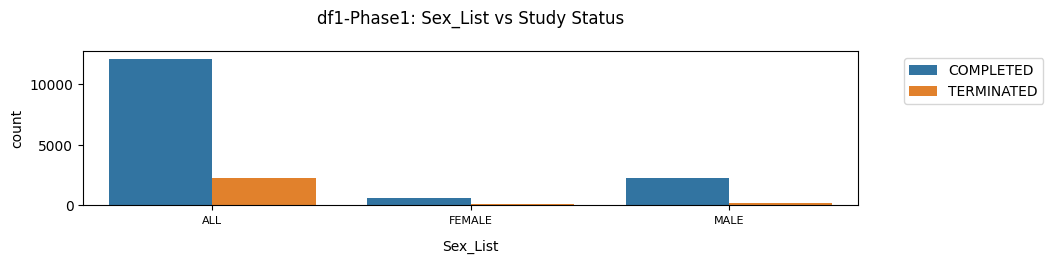

In [ ]:
Sex_List = log_fun("Sex_List", dfi, i, 'list', False, 0, 'FEMALE')

## Study Design

### Allocation_Bin

df1-Phase 1:
Allocation_Bin vs Study Status (Termination)



Study_Status_Bin               COMPLETED  TERMINATED
Allocation_Bin NON_RANDOMIZED       6492        1721
               RANDOMIZED           8425         825

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                 0.03528
Time:                        04:51:01   Log-Likelihood:                -6997.3
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                2.634e-113
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.3277      0.027    -48.969      0.000      -1.381      -1.275
RANDOMIZED    -0.9959      0.045    -21.911      0.000      -1.085      -0.907


df1-Phase1: Allocation_Bin p-values:
[const       

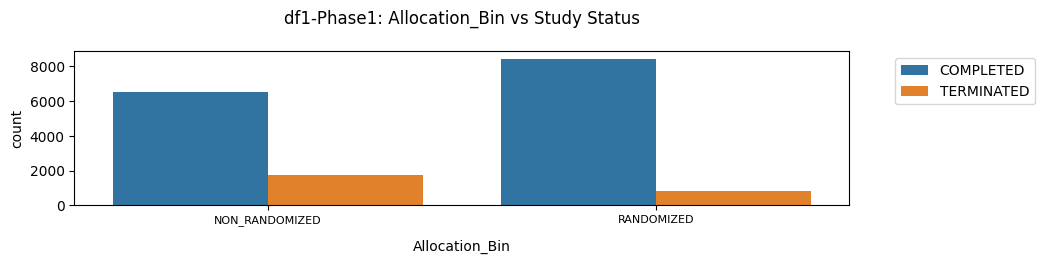

In [138]:
Allocation_Bin = log_fun("Allocation_Bin", dfi, i, 'list', False, 0, 'NON_RANDOMIZED')

### Masking_List


df1-Phase 1:
Masking_List vs Study Status (Termination)



Study_Status_Bin        COMPLETED  TERMINATED
Masking_List DOUBLE          1955         216
             MASK_NONE       9686        1935
             QUADRUPLE       1669         191
             SINGLE           697          73
             TRIPLE           910         131

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17458
Method:                           MLE   Df Model:                            4
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                0.009085
Time:                        04:51:02   Log-Likelihood:                -7187.2
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 1.613e-27
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.6106      0.025    -64.680      0.000      -1.659      -1.562
DOUBLE        -0.5924      0.076     -7.804      0.000      -0.741      -0.444
QUADRUPLE     -0.5568      0.080     -6.931      0.0

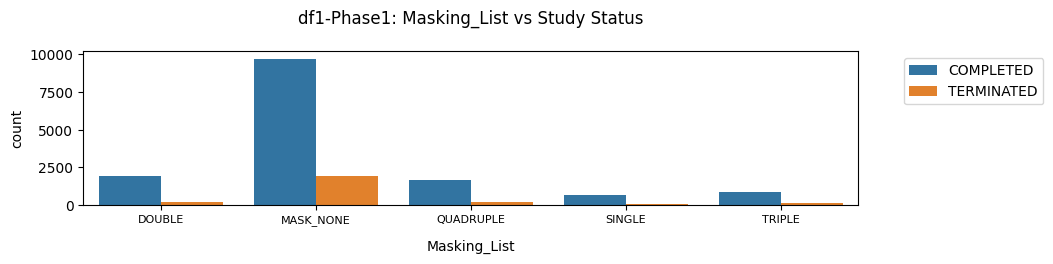

In [139]:
Masking_List = log_fun("Masking_List", dfi, i, 'list', False, 0, 'MASK_NONE')

### Masking_Detail_List

df1-Phase 1:
Masking_Detail_List vs Study Status (Termination)



Study_Status_Bin                       COMPLETED  TERMINATED
Masking_Detail_List CARE_PROVIDER           2280         286
                    INVESTIGATOR            4392         521
                    MASK_DET_NONE           9686        1935
                    OUTCOMES_ASSESSOR       2356         262
                    PARTICIPANT             4985         593

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17458
Method:                           MLE   Df Model:                            4
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                0.008281
Time:                        04:51:02   Log-Likelihood:                -7193.1
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 5.009e-25
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.6215      0.025    -65.398      0.000      -1.670      -1.573
CARE_PROVIDER         0.2801      0.103      2.728      0.006       0.079       0.481
INVESTIGATOR         -0.

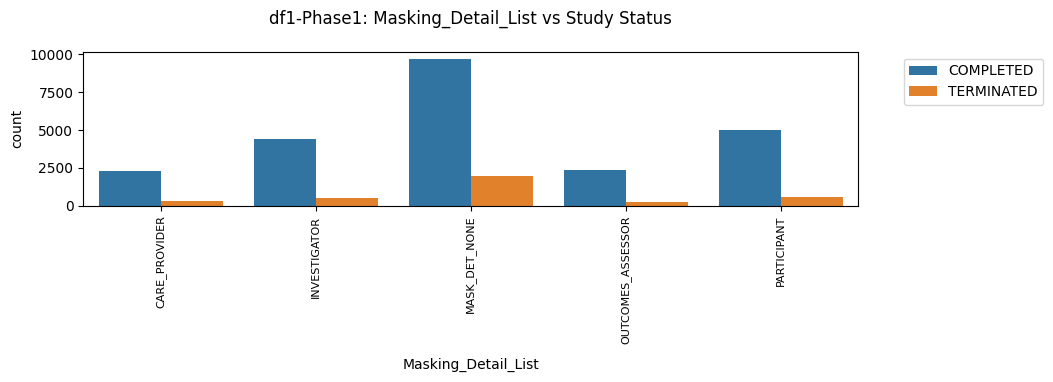

In [140]:
Masking_Detail_List = log_fun("Masking_Detail_List", dfi, i, 'list', False, 90, 'MASK_DET_NONE')


#### Format

In [141]:
Masking_aic = fun_compare(i,
                         Masking_List = Masking_List[0],
                         Masking_Detail_List = Masking_Detail_List[0])

### Primary_Purpose_List


df1-Phase 1:
Primary_Purpose_List vs Study Status (Termination)



Study_Status_Bin                      COMPLETED  TERMINATED
Primary_Purpose_List BASIC_SCIENCE         2221         188
                     DIAGNOSTIC             257          84
                     PREVENTION             867          83
                     PRIM_PURP_OTHER       2258         189
                     SUPPORTIVE_CARE        102          25
                     TREATMENT             9212        1977

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17457
Method:                           MLE   Df Model:                            5
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                 0.02411
Time:                        04:51:02   Log-Likelihood:                -7078.3
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 2.036e-73
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -2.4808      0.076    -32.757      0.000      -2.629      -2.332
BASIC_SCIENCE       0.0122      0.107      0.113      0.910      -0.198       0.222
DIAGNOSTIC          1.3629      

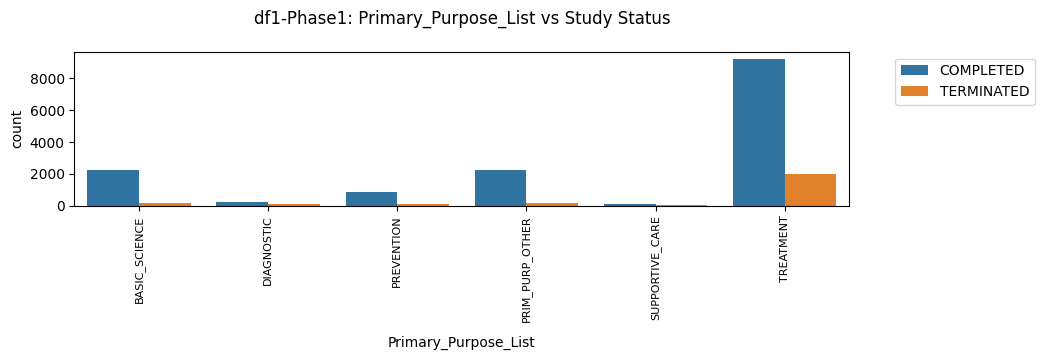

In [142]:
Primary_Purpose_List = log_fun("Primary_Purpose_List", dfi, i, 'list', False, 90, 'PRIM_PURP_OTHER')

## Arms

### Arm_Counts

df1-Phase 1:
Arm_Counts vs Study Status


count    17463.000000
mean         2.798145
std          2.392572
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         44.000000
Name: Arm_Counts, dtype: float64


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                0.003002
Time:                        04:51:03   Log-Likelihood:                -7231.4
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 4.140e-11
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------

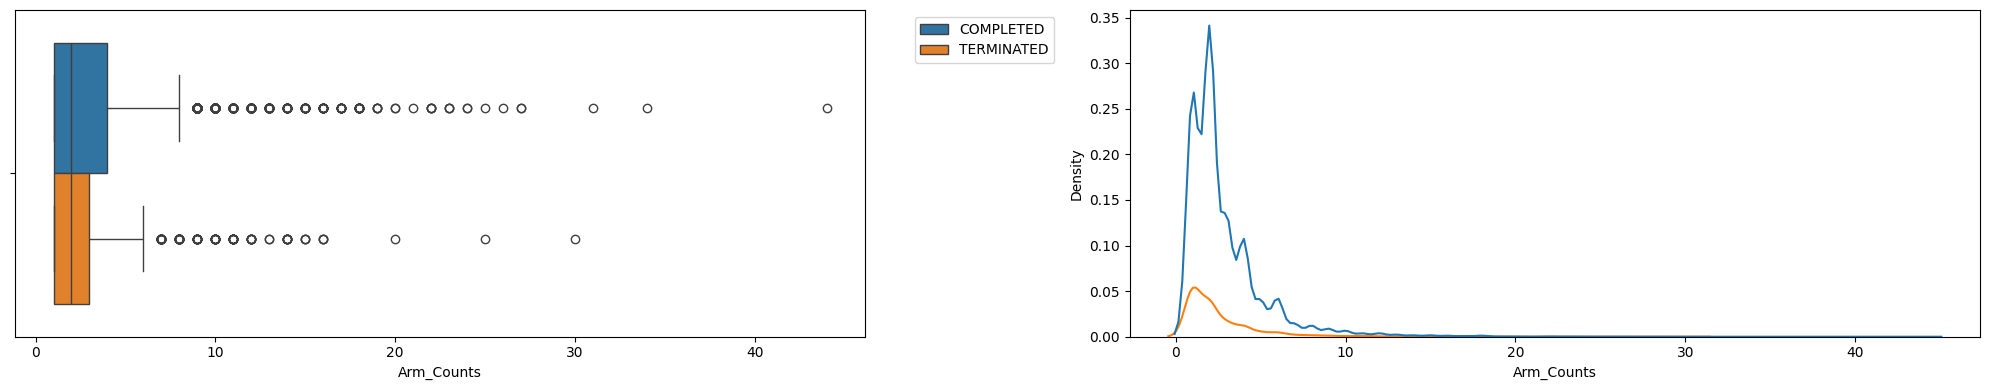

In [143]:
Arm_Counts = Arm_Counts = log_fun_cont("Arm_Counts", dfi, i)

### Arm_Counts_Log
- Arm_Counts despite mostly have the ditribution around small values (0,1,2 etc.) they also have a wide range of values in the remaining distribution.
- That is why they were checked as Log too

df1-Phase 1:
Arm_Counts vs Study Status


count    17463.000000
mean         2.798145
std          2.392572
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         44.000000
Name: Arm_Counts, dtype: float64


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                0.003002
Time:                        04:51:04   Log-Likelihood:                -7231.4
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 4.140e-11
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------

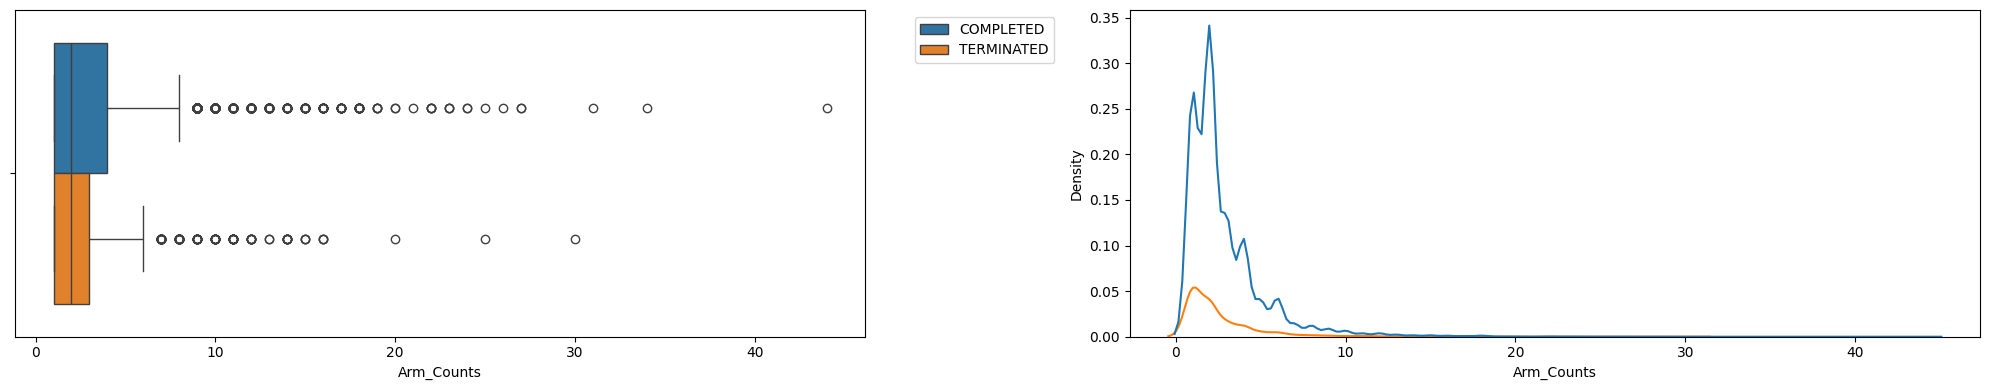

In [144]:
Arm_Counts_Log = Arm_Counts_Log = log_fun_cont("Arm_Counts", dfi, i)

### Arm_Categ

df1-Phase 1:
Arm_Categ vs Study Status

p-value: 1.5468341924186556e-10 < 0.05

------------------------------------------------------------------------------------------------------------

df1-Phase 1:
Arm_Categ vs Study Status (Termination)



Study_Status_Bin  COMPLETED  TERMINATED
Arm_Categ 1–2          9213        1742
          3–44         5704         804

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                0.002900
Time:                        04:51:04   Log-Likelihood:                -7232.1
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 8.798e-11
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.6657      0.026    -63.753      0.000      -1.717      -1.614
Arm_Categ     -0.2936      0.046     -6.404      0.000      -0.383      -0.204


df1-Phase1: Arm_Categ p-values:
[const        0.00

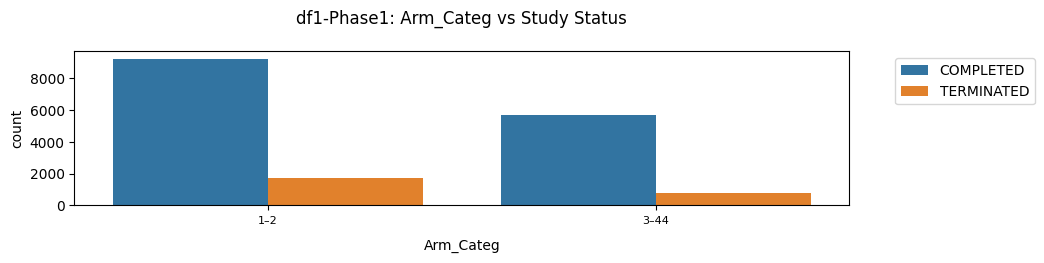

In [145]:
chi2_fun('Arm_Categ', dfi, i)
#### Log_Fun
Arm_Categ = log_fun('Arm_Categ', dfi, i, 'bin', True, 0)

#### Format
- Risk of Sparsity with categ

In [3]:
Arm_Counts_aic = fun_compare(i, Arm_Counts = Arm_Counts[0], Arm_Counts_Log = Arm_Counts_Log[0], Arm_Categ = Arm_Categ[0])
Arm_Counts_aic

NameError: name 'fun_compare' is not defined

In [147]:
#dfi = dfi.drop(columns = ['Arm_Counts', 'Arm_Categ'], axis = 1)

## Intervention_Model_List

df1-Phase 1:
Intervention_Model_List vs Study Status (Termination)



Study_Status_Bin                               COMPLETED  TERMINATED
Intervention_Model_List CROSSOVER                   3396         173
                        FACTORIAL, SEQUENTIAL       1714         465
                        PARALLEL                    5306         767
                        SINGLE_GROUP                4501        1141

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17459
Method:                           MLE   Df Model:                            3
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                 0.03958
Time:                        04:51:05   Log-Likelihood:                -6966.1
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                4.068e-124
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -1.3724      0.033    -41.406      0.000      -1.437      -1.307
CROSSOVER                -1.6048      0.085    -18.946      0.000      -1.771      -1.439
FACTORIA

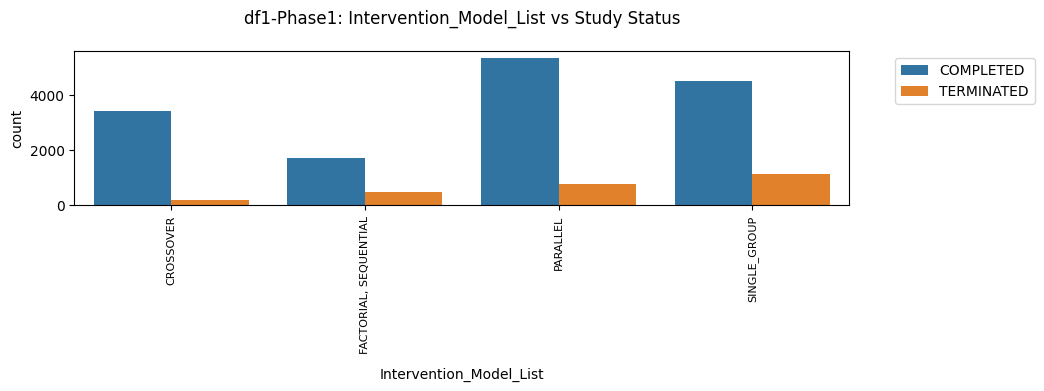

In [148]:
Intervention_Model_List = log_fun("Intervention_Model_List", dfi, i, 'list', False, 90, 'SINGLE_GROUP' )

## Intervention_Type_List

df1-Phase 1:
Intervention_Type_List vs Study Status (Termination)



Study_Status_Bin                           COMPLETED  TERMINATED
Intervention_Type_List BEHAVIORAL                137          16
                       BIOLOGICAL               1548         363
                       DEVICE                    339          78
                       DIETARY_SUPPLEMENT        143          11
                       DRUG                    11975        1977
                       INTERV_OTHER             1058         220
                       INTERV_UNSPES             314         122
                       PROCEDURE                 196          92

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17455
Method:                           MLE   Df Model:                            7
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                0.009802
Time:                        04:51:05   Log-Likelihood:                -7182.0
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 1.767e-27
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -1.9108      0.065    -29.463      0.000      -2.038      -1.784
BEHAVIORAL            -0.2913      0.270     -1.078      0.281      -0.821       0.239
BIOLOGICAL          

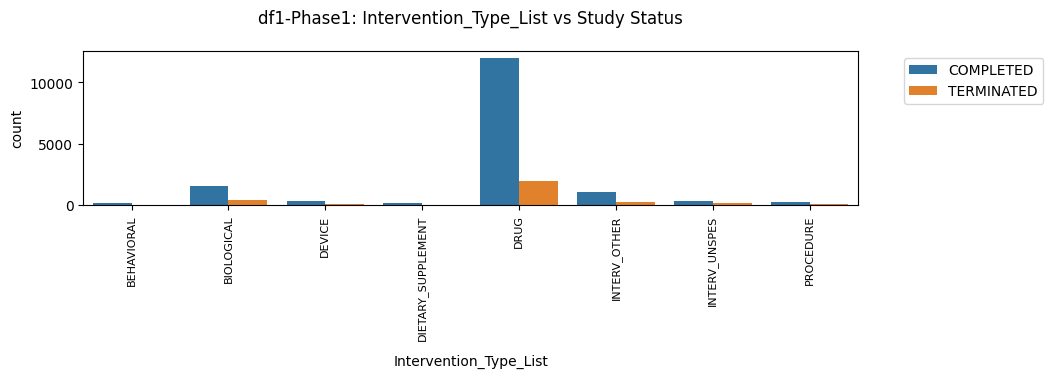

In [149]:
Intervention_Type_List = log_fun("Intervention_Type_List", dfi, i, 'list', False, 90, 'INTERV_OTHER')

## Intervention_Type_Counts


df1-Phase 1:
Intervention_Type_Counts vs Study Status


count    17463.000000
mean         1.064479
std          0.270468
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          4.000000
Name: Intervention_Type_Counts, dtype: float64


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                0.009939
Time:                        04:51:06   Log-Likelihood:                -7181.0
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 3.237e-33
                               coef    std err          z      P>|z|      [0.025      0

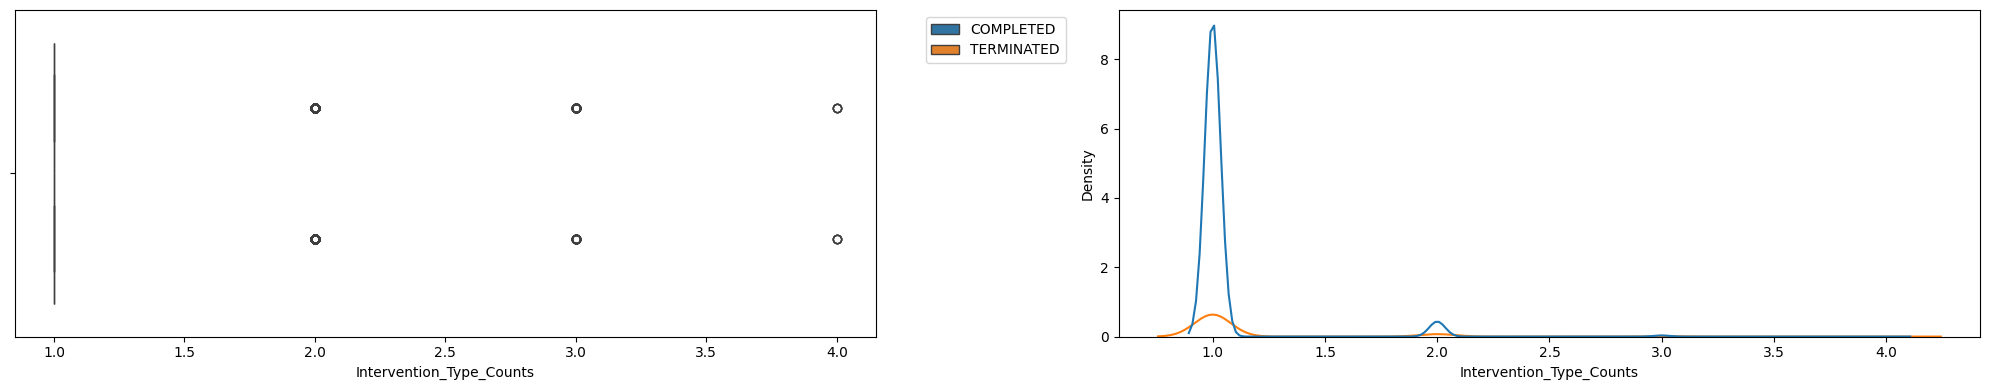

In [150]:
Intervention_Type_Counts = log_fun_cont("Intervention_Type_Counts", dfi, i)

## Intervention_Type_Categ

df1-Phase 1:
Intervention_Type_Categ vs Study Status

p-value: 3.388707713986093e-37 < 0.05

------------------------------------------------------------------------------------------------------------

df1-Phase 1:
Intervention_Type_Categ vs Study Status (Termination)



Study_Status_Bin             COMPLETED  TERMINATED
Intervention_Type_Categ 1        14184        2257
                        2–4        733         289

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                0.009403
Time:                        04:51:07   Log-Likelihood:                -7184.9
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 1.631e-31
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -1.8381      0.023    -81.108      0.000      -1.882      -1.794
Intervention_Type_Categ     0.9073      0.073     12.418      0.000       0.764       1.050


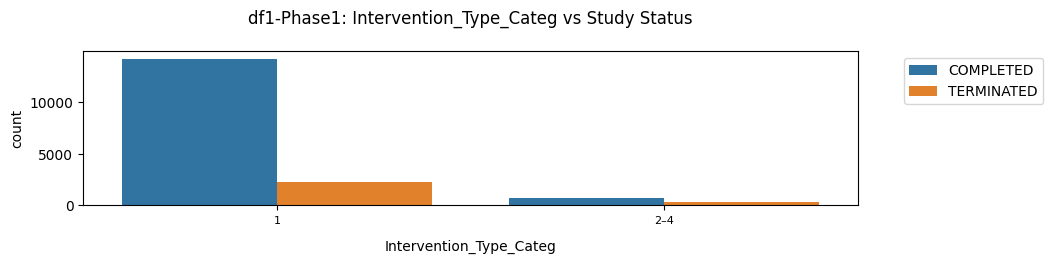

In [151]:
chi2_fun('Intervention_Type_Categ', dfi, i)
#### log_fun
Intervention_Type_Categ = log_fun('Intervention_Type_Categ', dfi, i, 'bin', True, 0)

#### Format
- Almost all distribution is at 1. Very small sample size except 1. No need for analysis.
- That is why _Log was not checks too.
- As categorical there is parsity risk.

In [152]:
Intervention_Type_Counts_aic = fun_compare(i, Intervention_Type_Counts = Intervention_Type_Counts[0], 
                                           Intervention_Type_Categ = Intervention_Type_Categ[0])
Intervention_Type_Counts_aic

,Intervention_Type_Counts,Intervention_Type_Categ,AIC_min
df1,,,
Intervention_Type_Counts,[14366.0],[14374.0],Intervention_Type_Counts


In [153]:
#dfi = dfi.drop(columns = ['Intervention_Type_Counts', 'Intervention_Type_Categ'], axis = 1)

## Intervention_Route

### Intervention_Route_List

df1-Phase 1:
Intervention_Route_List vs Study Status (Termination)



Study_Status_Bin                           COMPLETED  TERMINATED
Intervention_Route_List Injection               5324        1034
                        Inter_Route_Other       5476        1009
                        Oral                    4084         413
                        Surgical                 656         263
                        Topical                 1706         355

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17458
Method:                           MLE   Df Model:                            4
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                 0.01912
Time:                        04:51:07   Log-Likelihood:                -7114.4
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 8.051e-59
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.7612      0.032    -55.139      0.000      -1.824      -1.699
Injection      0.1011      0.045      2.261      0.024       0.013       0.189
Oral          -0.6069      0.057    -10.586      0.0

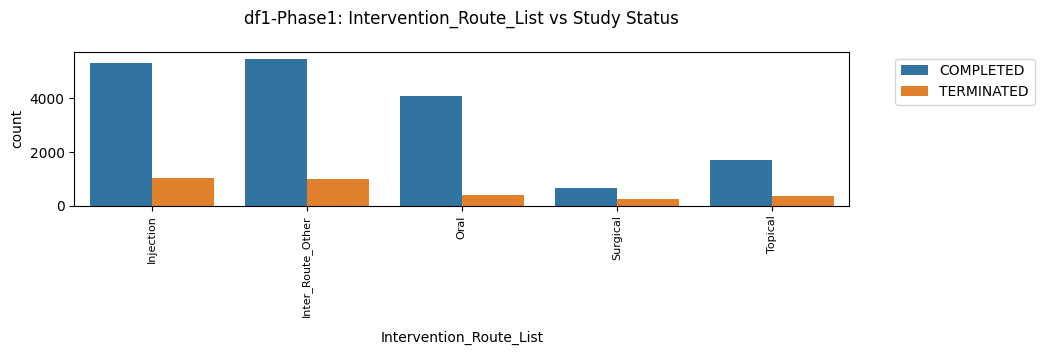

In [154]:
Intervention_Route_List = log_fun("Intervention_Route_List", dfi, i, 'list', False, 90, 'Inter_Route_Other')

### Intervention_Route_Counts

df1-Phase 1:
Intervention_Route_Counts vs Study Status


count    17463.000000
mean         1.163603
std          0.415703
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          4.000000
Name: Intervention_Route_Counts, dtype: float64


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                0.002133
Time:                        04:51:08   Log-Likelihood:                -7237.7
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 2.667e-08
                                coef    std err          z      P>|z|      [0.025    

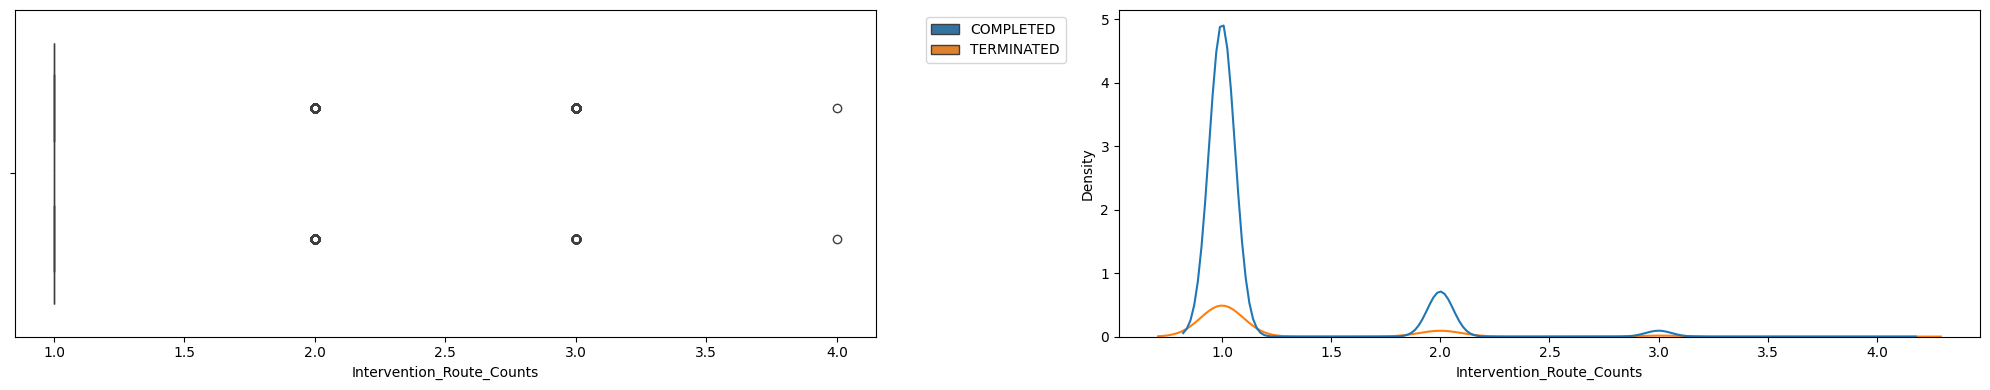

In [155]:
Intervention_Route_Counts = log_fun_cont("Intervention_Route_Counts", dfi, i)

### Intervention_Route_Categ

df1-Phase 1:
Intervention_Route_Categ vs Study Status

p-value: 1.0674809946036791e-07 < 0.05

------------------------------------------------------------------------------------------------------------

df1-Phase 1:
Intervention_Route_Categ vs Study Status (Termination)



Study_Status_Bin              COMPLETED  TERMINATED
Intervention_Route_Categ 1        12831        2087
                         2–4       2086         459

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                0.001874
Time:                        04:51:09   Log-Likelihood:                -7239.5
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 1.842e-07
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -1.8161      0.024    -76.946      0.000      -1.862      -1.770
Intervention_Route_Categ     0.3022      0.057      5.329      0.000       0.191       0.

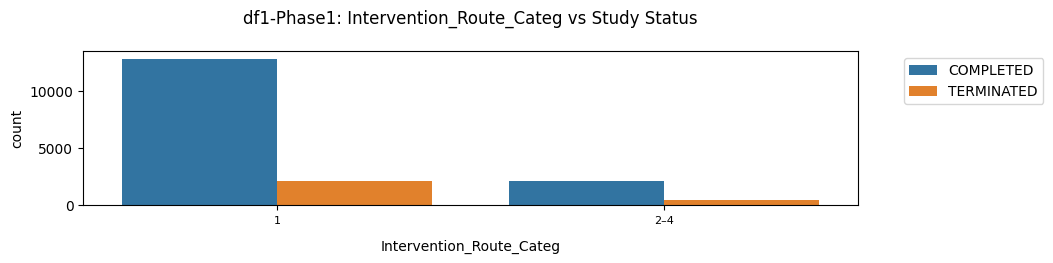

In [156]:
chi2_fun('Intervention_Route_Categ', dfi, i)
#### Log_Fun
Intervention_Route_Categ = log_fun('Intervention_Route_Categ', dfi, i, 'bin', True, 0)

#### Format
- As continues, it has too many discrite values at 1 and a small sample at 2. No need for analysis. 
- That is why _Log was not checks too.

In [157]:
Intervention_Route_Counts_aic = fun_compare(i, Intervention_Route_Counts = Intervention_Route_Counts[0], 
                                             Intervention_Route_Categ = Intervention_Route_Categ[0])
Intervention_Route_Counts_aic

,Intervention_Route_Counts,Intervention_Route_Categ,AIC_min
df1,,,
Intervention_Route_Counts,[14479.0],[14483.0],Intervention_Route_Counts


In [158]:
#dfi = dfi.drop(columns = ['Intervention_Route_Counts', 'Intervention_Route_Categ'], axis = 1)

## Locations

### City_Counts

df1-Phase 1:
City_Counts vs Study Status


count    17463.000000
mean         2.370498
std          4.316327
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        104.000000
Name: City_Counts, dtype: float64


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                0.005563
Time:                        04:51:09   Log-Likelihood:                -7212.8
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 2.626e-19
                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------

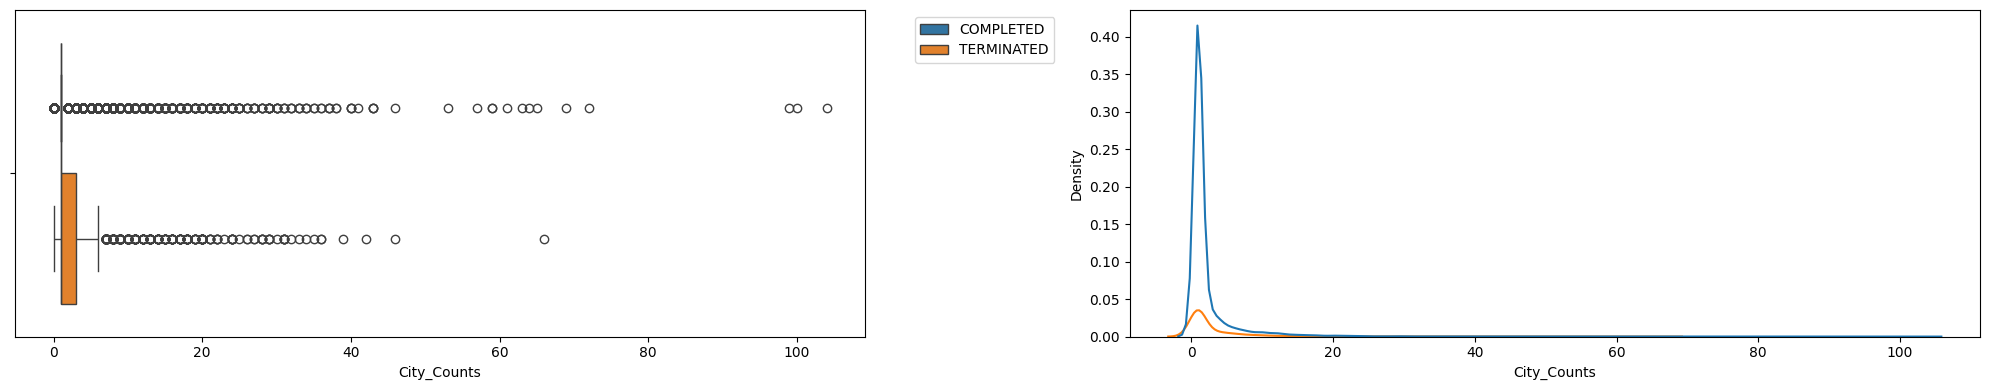

In [159]:
City_Counts = log_fun_cont("City_Counts", dfi, i)

### City_Counts_Log

df1-Phase 1:
City_Counts_Log vs Study Status


count    17463.000000
mean         0.936859
std          0.607372
min          0.000000
25%          0.693147
50%          0.693147
75%          1.098612
max          4.653960
Name: City_Counts_Log, dtype: float64


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                0.005525
Time:                        04:51:10   Log-Likelihood:                -7213.1
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 3.475e-19
                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------

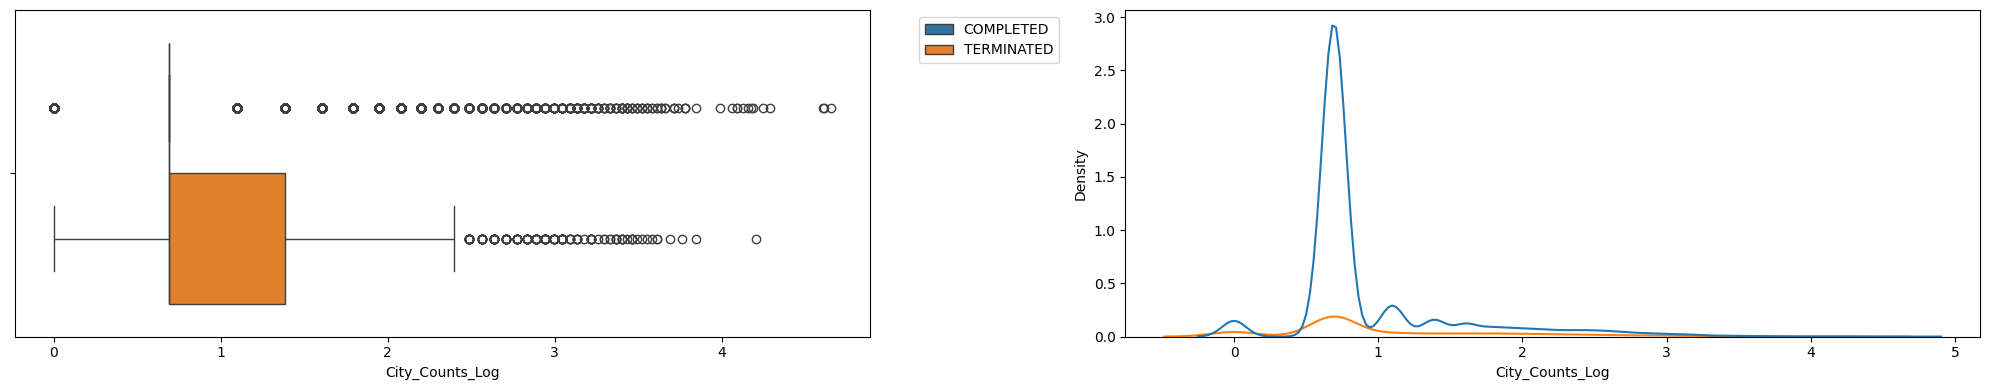

In [160]:
City_Counts_Log = log_fun_cont("City_Counts_Log", dfi, i)

### City_Categ

df1-Phase 1:
City_Categ vs Study Status

p-value: 4.1177088248193073e-38 < 0.05

------------------------------------------------------------------------------------------------------------

df1-Phase 1:
City_Categ vs Study Status (Termination)



Study_Status_Bin  COMPLETED  TERMINATED
City_Categ 0–1        11341        1627
           2–104       3576         919

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                 0.01086
Time:                        04:51:11   Log-Likelihood:                -7174.4
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 3.921e-36
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.9417      0.027    -73.242      0.000      -1.994      -1.890
City_Categ     0.5830      0.046     12.812      0.000       0.494       0.672


df1-Phase1: City_Categ p-values:
[const         0.

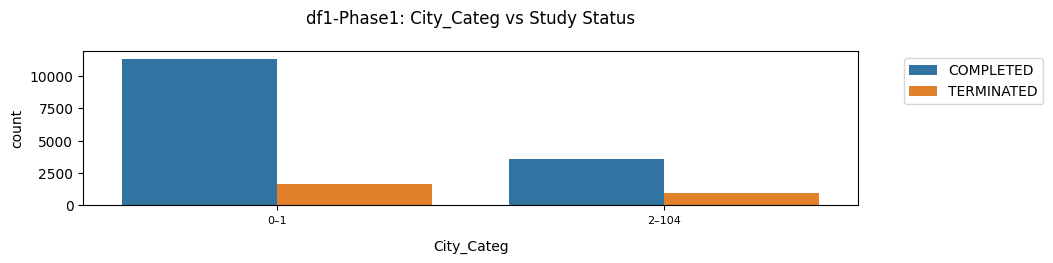

In [161]:
chi2_fun('City_Categ', dfi, i)
#### log_fun
City_Categ = log_fun('City_Categ', dfi, i, 'bin', False, 0)

#### Format
- Distribution is almost all at 1.
- Howver, the question answered from this feature is if multi vs single facilities.
- Categ is goind to be used. 


In [162]:
City_Counts_aic = fun_compare(i, City_Counts = City_Counts[0], 
                              City_Counts_Log = City_Counts_Log[0],
                              City_Categ = City_Categ[0]
                              )
City_Counts_aic

,City_Counts,City_Counts_Log,City_Categ,AIC_min
df1,,,,
City_Counts,[14430.0],[14430.0],[14353.0],City_Categ


In [163]:
#dfi = dfi.drop(columns = ['City_Counts', 'City_Categ'], axis = 1)

### Country_Counts


df1-Phase 1:
Country_Counts vs Study Status


count    17463.000000
mean         1.178263
std          1.052185
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         33.000000
Name: Country_Counts, dtype: float64


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                0.001852
Time:                        04:51:11   Log-Likelihood:                -7239.7
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 2.175e-07
                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------

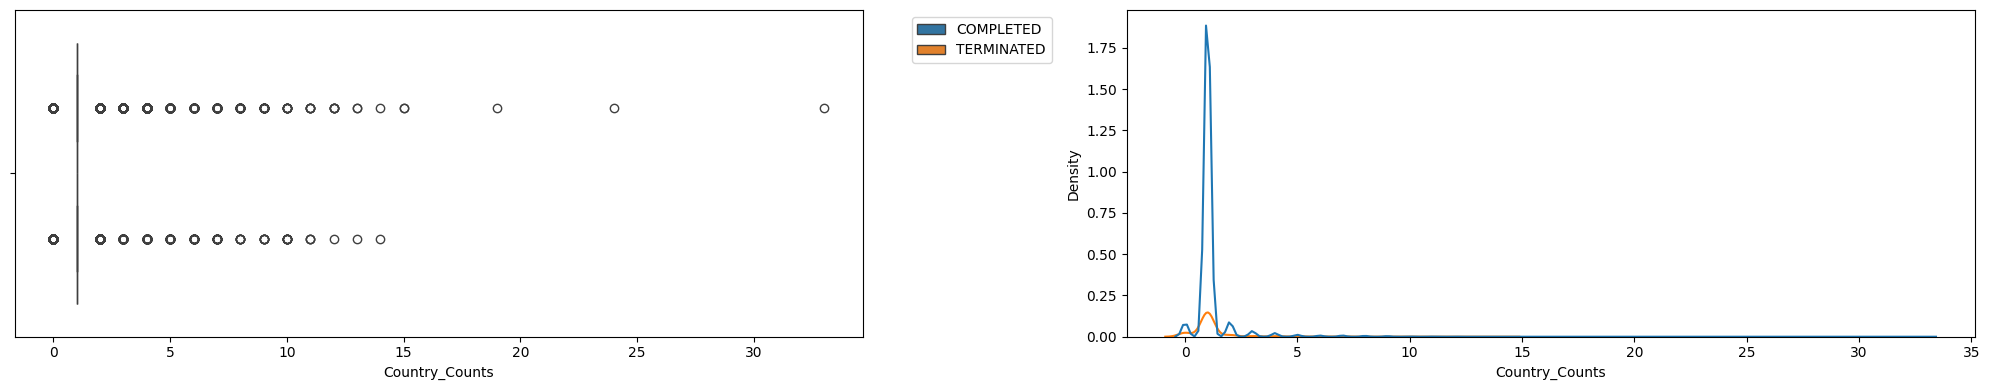

In [164]:
Country_Counts = log_fun_cont("Country_Counts", dfi, i)

### Country_Counts_Log

df1-Phase 1:
Country_Counts_Log vs Study Status


count    17463.000000
mean         0.724096
std          0.289934
min          0.000000
25%          0.693147
50%          0.693147
75%          0.693147
max          3.526361
Name: Country_Counts_Log, dtype: float64


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:               7.872e-06
Time:                        04:51:12   Log-Likelihood:                -7253.1
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                    0.7354
                         coef    std err          z      P>|z|      [0.025      0.975]
------------

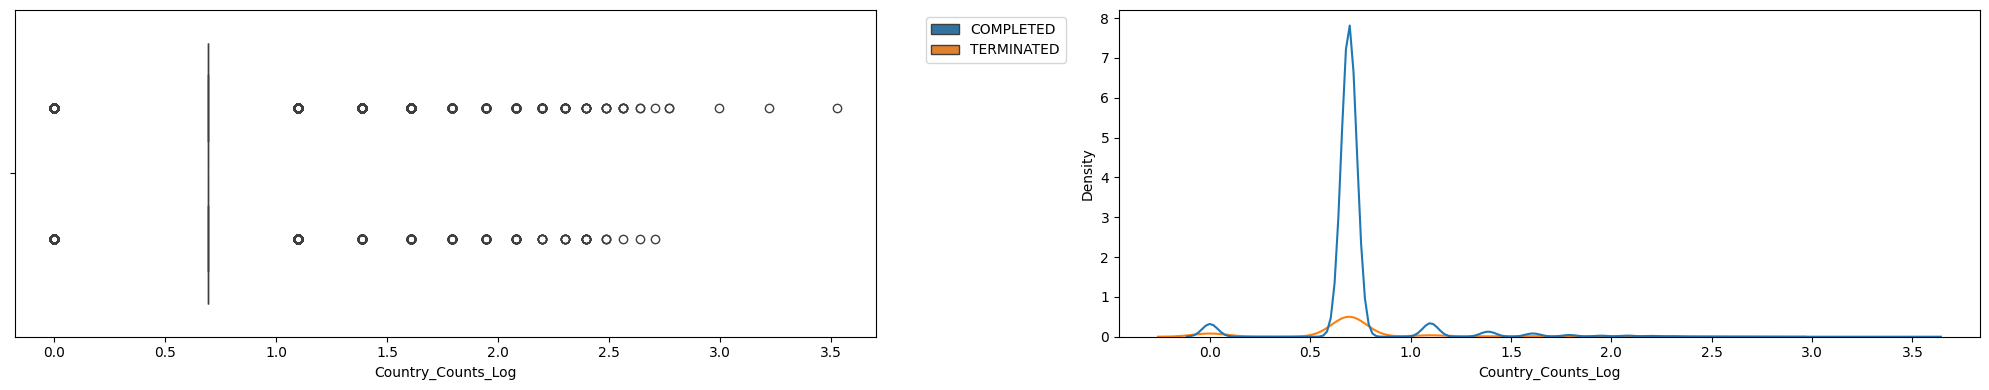

In [165]:
Country_Counts_Log = log_fun_cont("Country_Counts_Log", dfi, i)

### Global_Bin

df1-Phase 1:
Global_Bin vs Study Status

p-value: 2.277784801151224e-22 < 0.05

------------------------------------------------------------------------------------------------------------

df1-Phase 1:
Global_Bin vs Study Status (Termination)



Study_Status_Bin       COMPLETED  TERMINATED
Global_Bin Global_No       13747        2196
           Global_Yes       1170         350

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                0.005839
Time:                        04:51:13   Log-Likelihood:                -7210.8
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 3.466e-20
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.8342      0.023    -79.814      0.000      -1.879      -1.789
Global_Bin     0.6274      0.065      9.635      0.000       0.500       0.755


df1-Phase1: Global_Bin p-values:
[const         0.

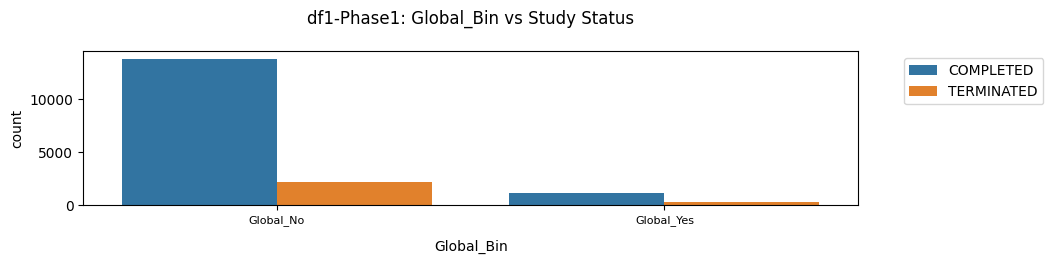

In [166]:
chi2_fun('Global_Bin', dfi, i)
#### log_fun
Global_Bin = log_fun('Global_Bin', dfi, i, 'bin', True, 0)

#### Format
- Sparse Risk with categ
- However, the question to answer is global/non-global trials.


In [167]:
Country_Counts_aic = fun_compare(i, Country_Counts = Country_Counts[0], 
                                 Country_Counts_Log = Country_Counts_Log[0],
                                 Global_Bin = Global_Bin[0])
Country_Counts_aic

,Country_Counts,Country_Counts_Log,Global_Bin,AIC_min
df1,,,,
Country_Counts,[14483.0],[14510.0],[14426.0],Global_Bin


In [168]:
#dfi = dfi.drop(columns = ['Country_Counts', 'Country_Counts_Log'], axis = 1)

### Continents_List 

df1-Phase 1:
Continents_List vs Study Status (Termination)



Study_Status_Bin               COMPLETED  TERMINATED
Continents_List Asia                3171         309
                Cont_Other          1626         464
                Europe              3806         551
                North America       7387        1625

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17459
Method:                           MLE   Df Model:                            3
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                 0.01510
Time:                        04:51:13   Log-Likelihood:                -7143.6
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 3.189e-47
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.9202      0.056    -34.366      0.000      -2.030      -1.811
Asia             -0.4458      0.076     -5.905      0.000      -0.594      -0.298
Europe           -0.0667      0.063     

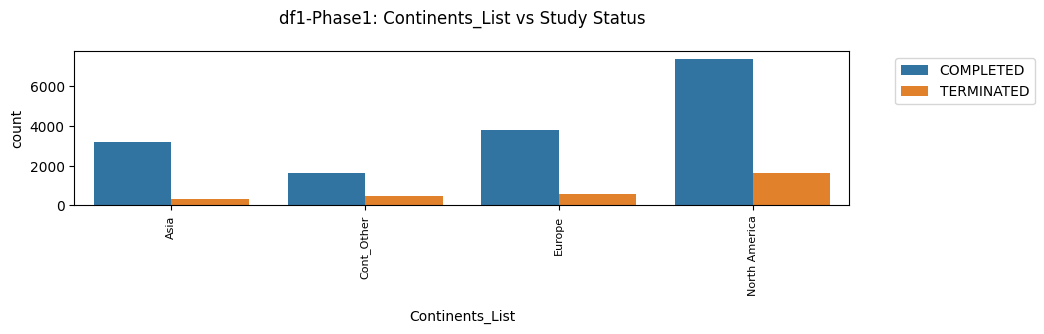

In [169]:
Continents_List = log_fun("Continents_List", dfi, i, 'list', False, 90, 'Cont_Other')

### Continent_Counts

df1-Phase 1:
Continent_Counts vs Study Status


count    17463.000000
mean         0.986028
std          0.491398
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          6.000000
Name: Continent_Counts, dtype: float64


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:               0.0005179
Time:                        04:51:14   Log-Likelihood:                -7249.4
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                  0.006124
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------

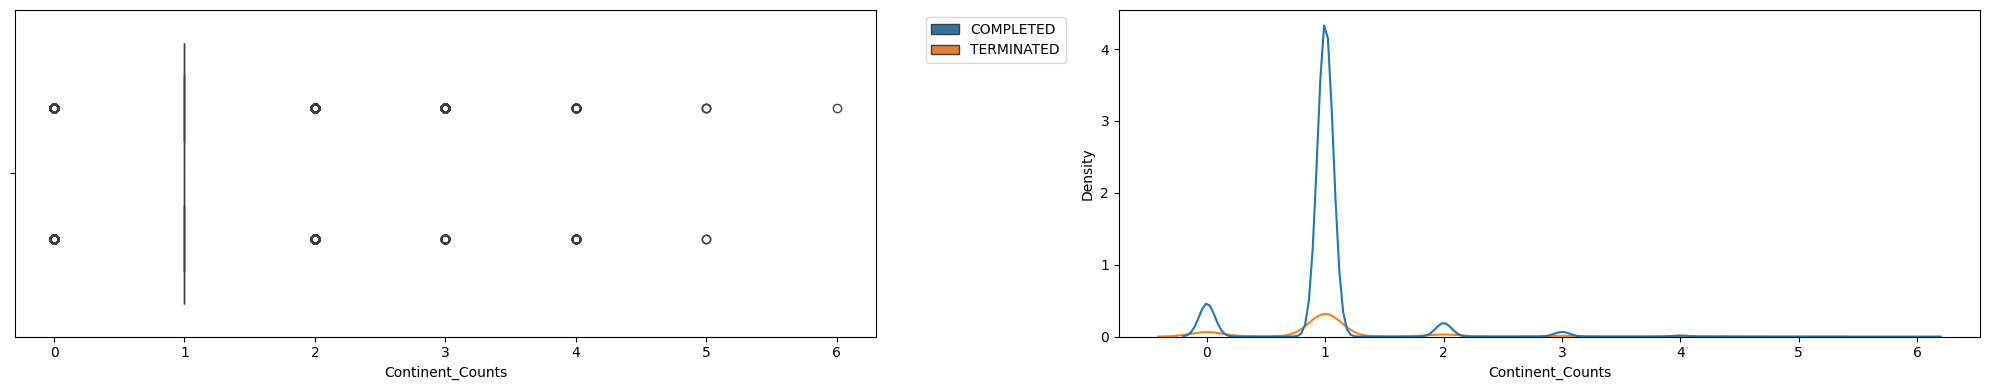

In [170]:
Continent_Counts = log_fun_cont("Continent_Counts", dfi, i)

### Continent_Counts_Log

df1-Phase 1:
Continent_Counts_Log vs Study Status


count    17463.000000
mean         0.655995
std          0.252348
min          0.000000
25%          0.693147
50%          0.693147
75%          0.693147
max          1.945910
Name: Continent_Counts_Log, dtype: float64


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:               0.0001896
Time:                        04:51:14   Log-Likelihood:                -7251.8
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                   0.09721
                           coef    std err          z      P>|z|      [0.025      0.975]
------

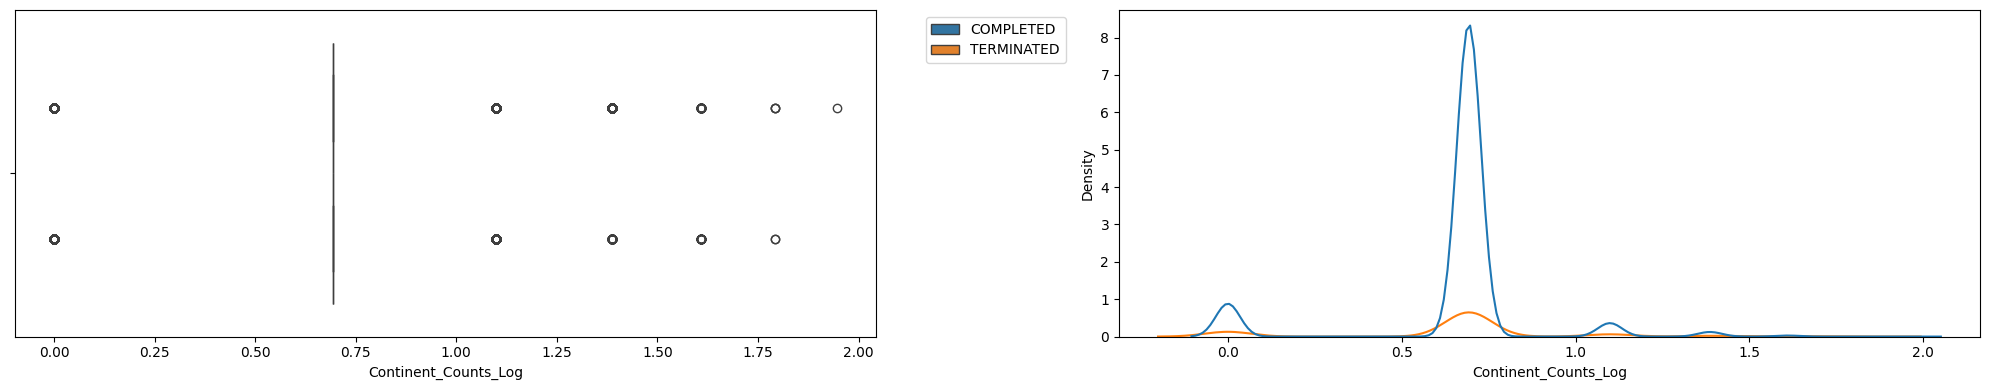

In [171]:
Continent_Counts_Log = log_fun_cont("Continent_Counts_Log", dfi, i)

### Continent_Categ

df1-Phase 1:
Continent_Categ vs Study Status

p-value: 2.652817354153259e-26 < 0.05

------------------------------------------------------------------------------------------------------------

df1-Phase 1:
Continent_Categ vs Study Status (Termination)



Study_Status_Bin     COMPLETED  TERMINATED
Continent_Categ 0–1      14131        2273
                2–6        786         273

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                0.006704
Time:                        04:51:15   Log-Likelihood:                -7204.5
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 6.121e-23
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -1.8272      0.023    -80.856      0.000      -1.872      -1.783
Continent_Categ     0.7695      0.074     10.427      0.000       0.625       0.914


df1-Phase1: Continent_Categ p-

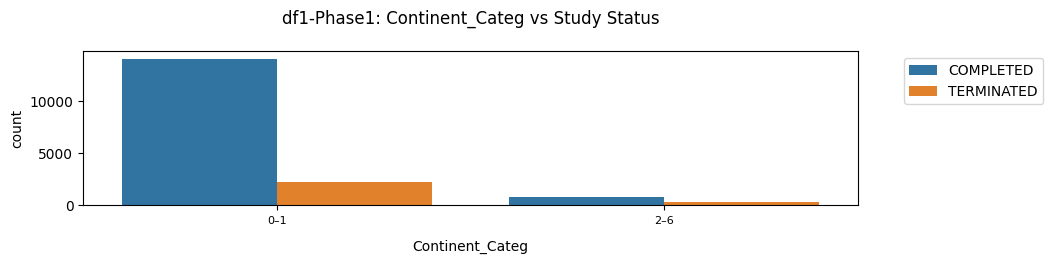

In [172]:
chi2_fun('Continent_Categ', dfi, i)
#### log_fun
Continent_Categ = log_fun('Continent_Categ', dfi, i, 'bin', True, 0)

#### Format
- Sparsity Risk with categ.
- However, question answered is global/global
- Will all Continent counts be dropped, as the global/non-global is answered through countries as well. 
- Also, Continenets are have more sparse risk than Countries.

In [173]:
Continent_Counts_aic = fun_compare(i, Continent_Counts = Continent_Counts[0], 
                                   Continent_Counts_Log = Continent_Counts_Log[0],
                                Continent_Categ = Continent_Categ[0]

                                   )
Continent_Counts_aic

,Continent_Counts,Continent_Counts_Log,Continent_Categ,AIC_min
df1,,,,
Continent_Counts,[14503.0],[14508.0],[14413.0],Continent_Categ


In [174]:
#dfi = dfi.drop(columns = ['Continent_Counts', 'Continent_Counts_Log', 'Continent_Categ'])

## Datetimes

### Start_Date_Year_Counts

df1-Phase 1:
Start_Date_Year_Counts vs Study Status


count        17463.0
mean     2016.879803
std         3.730381
min           2011.0
25%           2014.0
50%           2017.0
75%           2020.0
max           2024.0
Name: Start_Date_Year_Counts, dtype: Float64


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                0.003110
Time:                        04:51:16   Log-Likelihood:                -7230.6
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 1.854e-11
                             coef    std err          z      P>|z|      [0.025      0.975]
--------

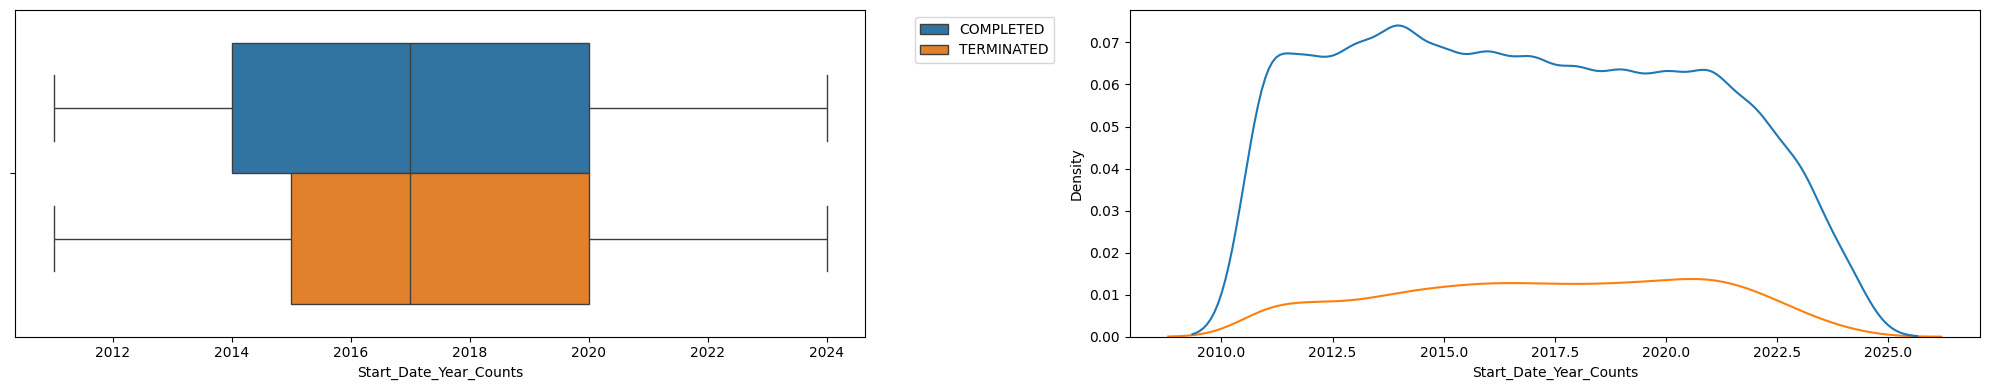

In [175]:
Start_Date_Year_Counts = log_fun_cont("Start_Date_Year_Counts", dfi, i)

### Start_Date_Year_Categ
- Categorization is covid dates oriented

df1-Phase 1:
Start_Date_Year_Categ vs Study Status

p-value: 2.457444041769866e-07 < 0.05

------------------------------------------------------------------------------------------------------------

df1-Phase 1:
Start_Date_Year_Categ vs Study Status (Termination)



Study_Status_Bin                 COMPLETED  TERMINATED
Start_Date_Year_Categ 2011-2018       9564        1496
                      2019-2024       5353        1050

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                0.001828
Time:                        04:51:17   Log-Likelihood:                -7239.9
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 2.611e-07
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -1.8552      0.028    -66.727      0.000      -1.910      -1.801
Start_Date_Year_Categ     0.2263      0.044      5.176      0.000       0.141       0.312


df1-Ph

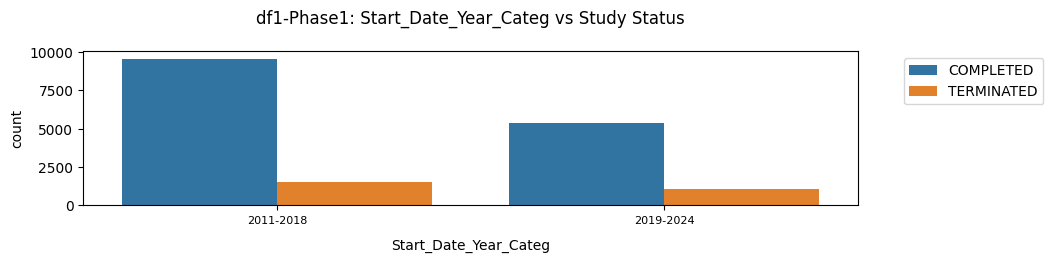

In [176]:
chi2_fun("Start_Date_Year_Categ", dfi, i)
#### log_fun
Start_Date_Year_Categ = log_fun("Start_Date_Year_Categ", dfi, i, 'bin', True, 0)

### Completion_Date_Year 
- will not run AIC --> Date - Year itself is not a feature affecting the outcome.



df1-Phase 1:
Completion_Date_Year_Counts vs Study Status


count        17463.0
mean     2018.447804
std         3.763679
min           2011.0
25%           2015.0
50%           2019.0
75%           2022.0
max           2024.0
Name: Completion_Date_Year_Counts, dtype: Float64


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                 0.01320
Time:                        04:51:17   Log-Likelihood:                -7157.4
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 1.549e-43
                                  coef    std err          z      P>|z|      [0.025      

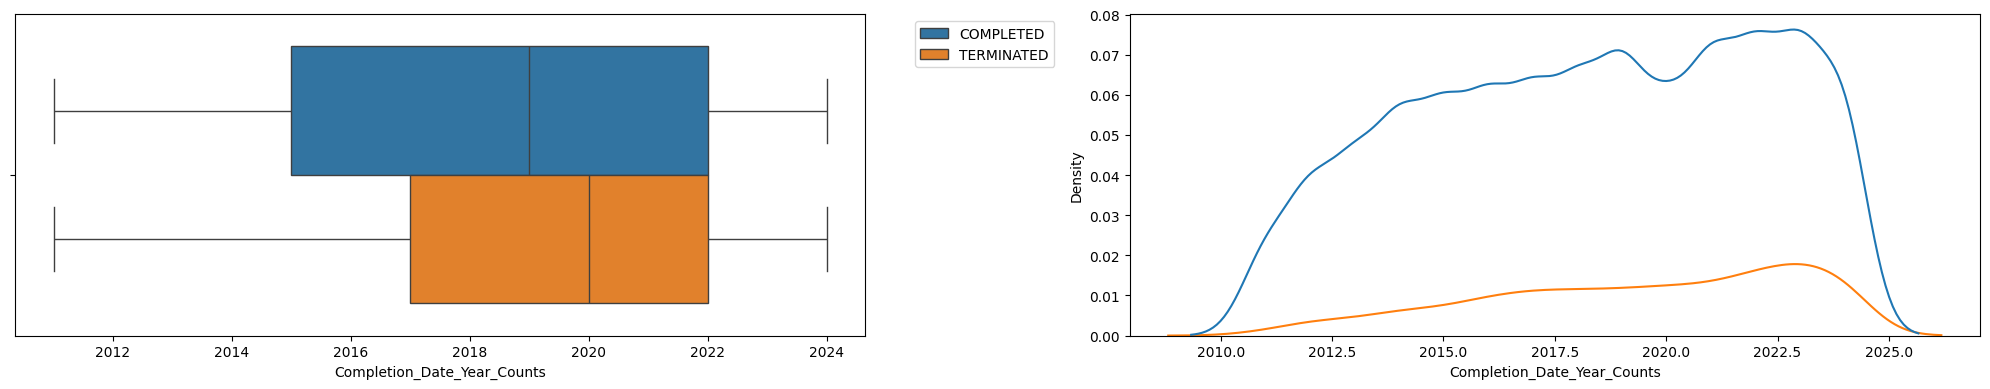

In [177]:
Completion_Date_Year_Counts = log_fun_cont("Completion_Date_Year_Counts", dfi, i)
# Plot is higher to completion as year pass --> Logic as trials of dataset are 2011-2024. 
# At 2011 that all started no trial was finished.

### Completion_Date_Year_Categ
- Categorization is covid dates oriented

df1-Phase 1:
Completion_Date_Year_Categ vs Study Status

p-value: 2.2936549697392394e-25 < 0.05

------------------------------------------------------------------------------------------------------------

df1-Phase 1:
Completion_Date_Year_Categ vs Study Status (Termination)



Study_Status_Bin                      COMPLETED  TERMINATED
Completion_Date_Year_Categ 2011-2018       7438         985
                           2019-2024       7479        1561

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                0.007566
Time:                        04:51:18   Log-Likelihood:                -7198.3
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 1.108e-25
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -2.0216      0.034    -59.625      0.000      -2.088      -1.955
Completion_Date_Year_Categ     0.4549      0.044     10.371      0.000       0.369 

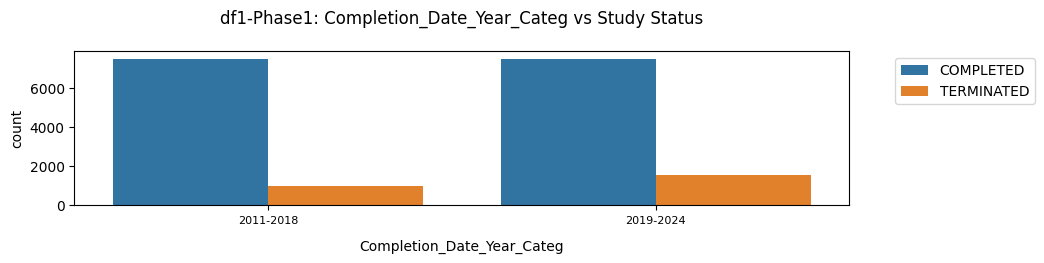

In [178]:
chi2_fun("Completion_Date_Year_Categ", dfi, i)
### log_fun
Completion_Date_Year_Categ = log_fun("Completion_Date_Year_Categ", dfi, i, 'bin', True, 0)

#### Drop

In [179]:
#dfi = dfi.drop(columns = ['Start_Date_Year_Counts', 'Start_Date_Year_Categ', 'Completion_Date_Year_Counts', 'Completion_Date_Year_Categ'], axis = 1)

### Completion_Gap_Counts

- Notice Termination main Distribution median = Around 20 participants --> cutpoint
- A trials holding too long may risk patients dropping out.

df1-Phase 1:
Completion_Gap_Counts vs Study Status


count      17463.0
mean     19.108229
std      21.548946
min            0.0
25%            4.0
50%           11.0
75%           27.0
max          150.0
Name: Completion_Gap_Counts, dtype: Float64


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                 0.01317
Time:                        04:51:19   Log-Likelihood:                -7157.6
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 1.855e-43
                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------

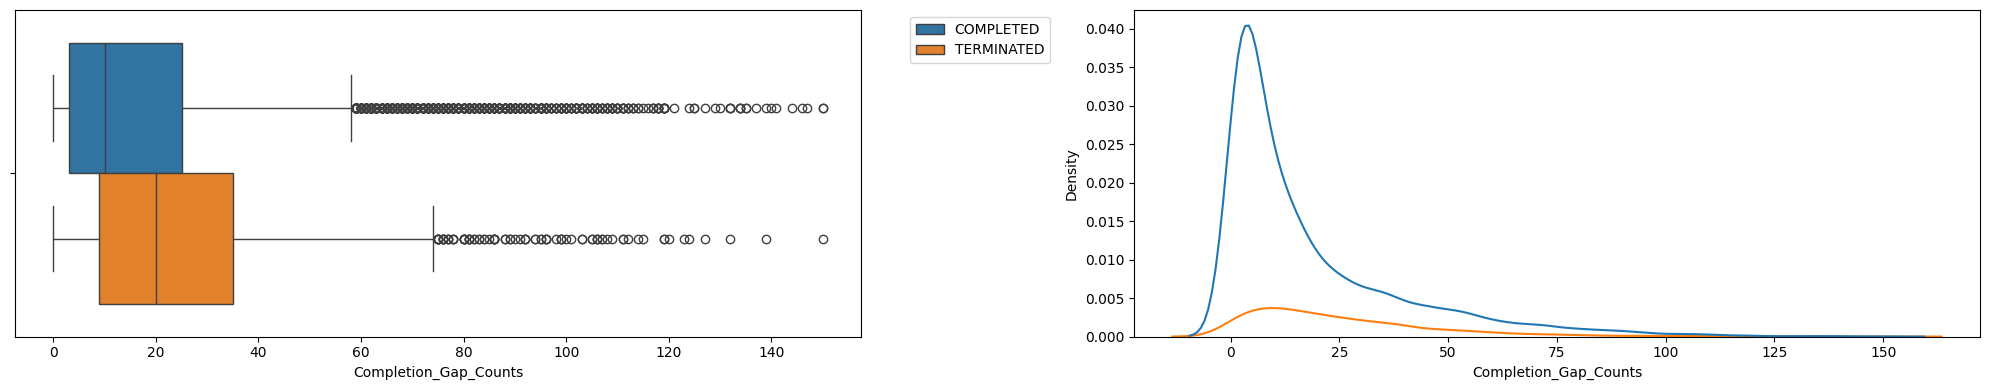

In [180]:
Completion_Gap_Counts = log_fun_cont("Completion_Gap_Counts", dfi, i)

### Completion_Gap_Log

df1-Phase 1:
Completion_Gap_Log vs Study Status


count     17463.0
mean     2.415664
std      1.174396
min           0.0
25%      1.609438
50%      2.484907
75%      3.332205
max       5.01728
Name: Completion_Gap_Log, dtype: Float64


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                 0.02935
Time:                        04:51:19   Log-Likelihood:                -7040.2
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                 1.340e-94
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------

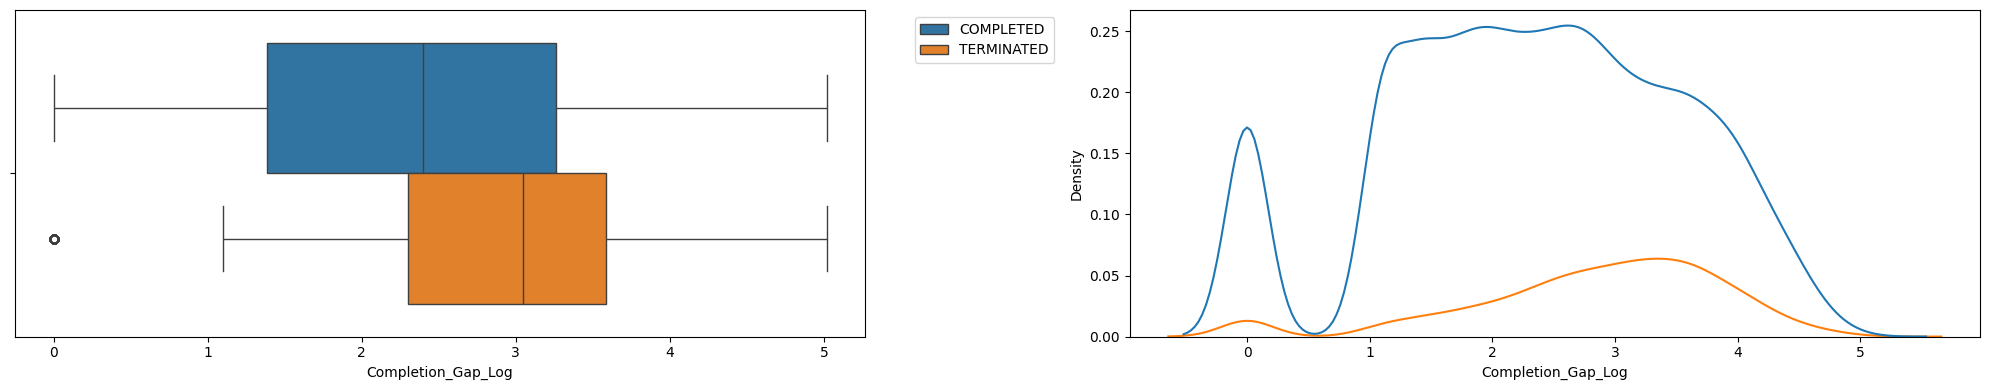

In [181]:
Completion_Gap_Log = log_fun_cont("Completion_Gap_Log", dfi, i)

### Completion_Gap_Categ

df1-Phase 1:
Completion_Gap_Categ vs Study Status

p-value: 1.652407757734566e-104 < 0.05

------------------------------------------------------------------------------------------------------------

df1-Phase 1:
Completion_Gap_Categ vs Study Status (Termination)



Study_Status_Bin             COMPLETED  TERMINATED
Completion_Gap_Categ 0–11         8150         798
                     12–160       6767        1748

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                 0.03315
Time:                        04:51:20   Log-Likelihood:                -7012.7
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                1.383e-106
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -2.3237      0.037    -62.646      0.000      -2.396      -2.251
Completion_Gap_Categ     0.9701      0.046     21.191      0.000       0.880       1.060


df1-Phase1

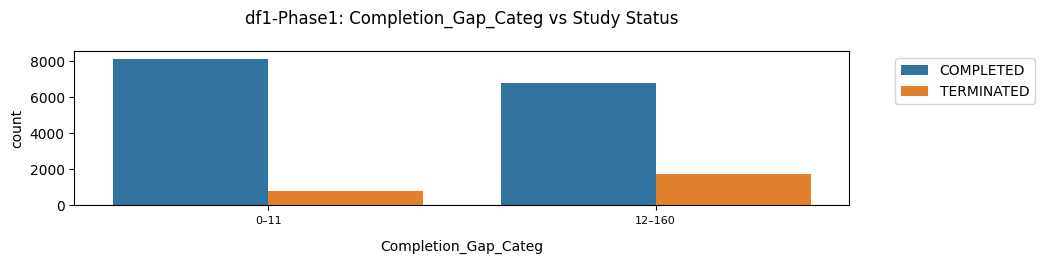

In [182]:
chi2_fun('Completion_Gap_Categ', dfi, i)
#### log_fun
Completion_Gap_Categ = log_fun('Completion_Gap_Categ', dfi, i, 'bin', True, 0)

#### Format
- Start date is the date first partcipants enrolled.
- Completion date is day last participant took intervention.
- Thus, it is not a predesigned characteristic and is not goind to be used as feature.

In [183]:
#dfi = dfi.drop(columns = ['Completion_Gap_Counts', 'Completion_Gap_Log', 'Completion_Gap_Categ'], axis=1)

## Enrollment

### Enrollment_Counts

df1-Phase 1:
Enrollment_Counts vs Study Status


count    17463.000000
mean        43.022562
std         71.374647
min          0.000000
25%         15.000000
50%         28.000000
75%         49.000000
max       3052.000000
Name: Enrollment_Counts, dtype: float64


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                 0.09171
Time:                        04:51:21   Log-Likelihood:                -6588.0
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                2.879e-291
                        coef    std err          z      P>|z|      [0.025      0.975]
---------------

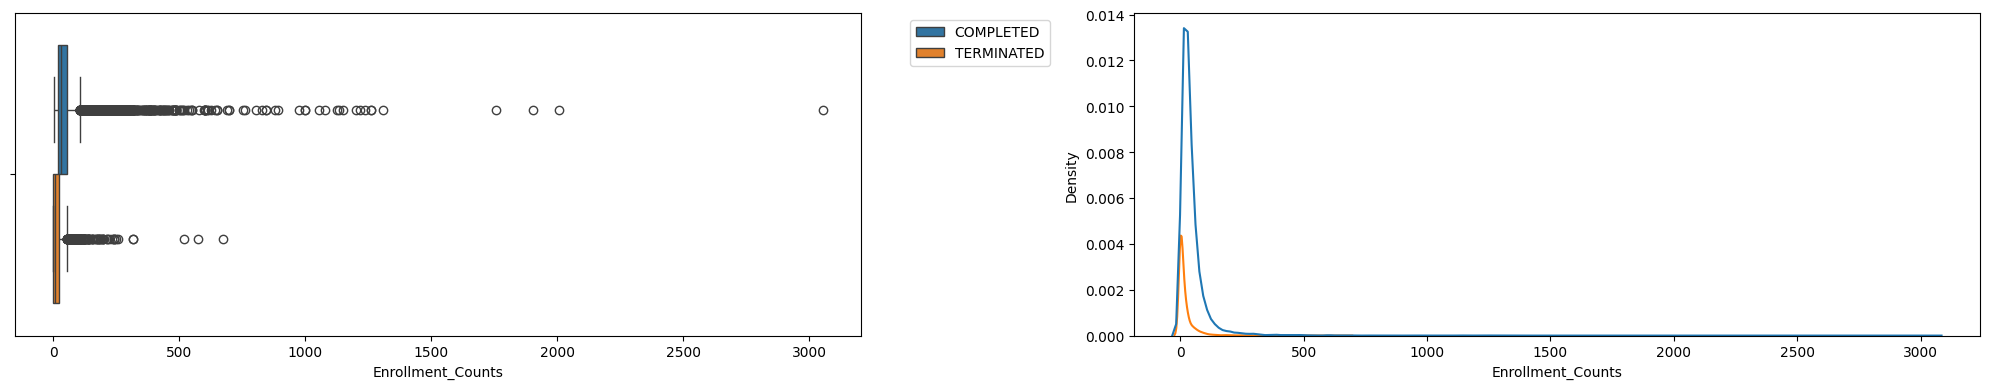

In [184]:
Enrollment_Counts = log_fun_cont("Enrollment_Counts", dfi, i)

Text(0.5, 0.98, 'Enrollment_Counts Scatterplots by Phase')

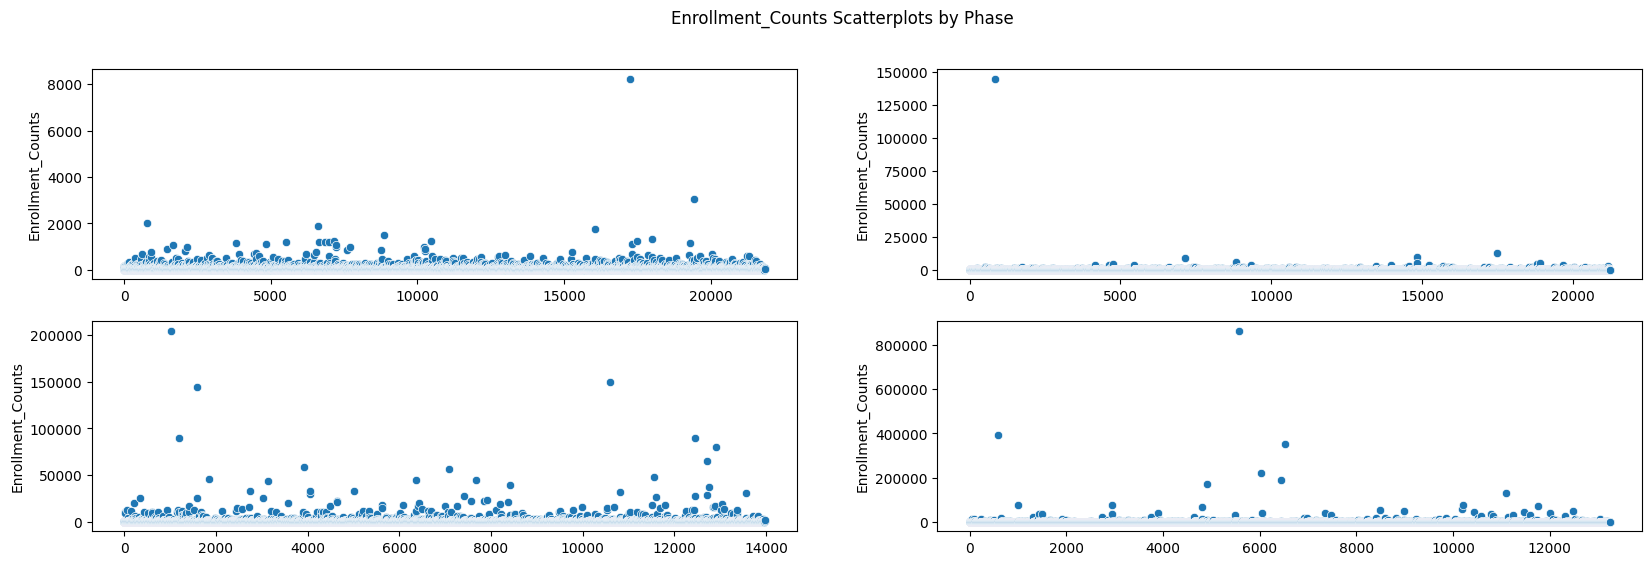

In [185]:
plt.fig, ax = plt.subplots(figsize=(20, 6), nrows = 2, ncols = 2)

sns.scatterplot(df1['Enrollment_Counts'], ax=ax[0,0])
sns.scatterplot(df2['Enrollment_Counts'], ax=ax[0,1])
sns.scatterplot(df3['Enrollment_Counts'], ax=ax[1,0])
sns.scatterplot(df4['Enrollment_Counts'], ax=ax[1,1])

plt.fig.suptitle('Enrollment_Counts Scatterplots by Phase')

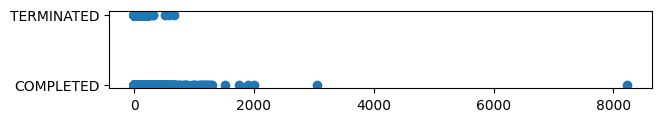

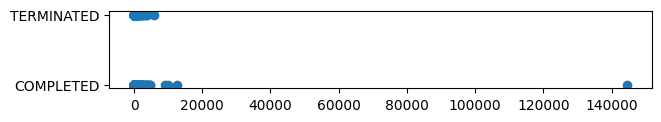

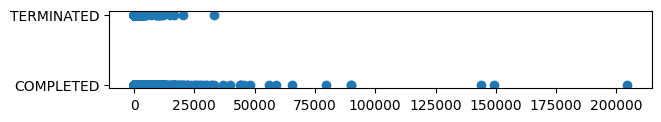

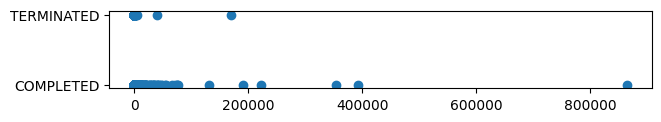

In [186]:
plt.figure(figsize=(7,1))
plt.scatter(df1['Enrollment_Counts'], df1['Study_Status_Bin'])
plt.figure(figsize=(7,1))
plt.scatter(df2['Enrollment_Counts'], df2['Study_Status_Bin'])
plt.figure(figsize=(7,1))
plt.scatter(df3['Enrollment_Counts'], df3['Study_Status_Bin'])
plt.figure(figsize=(7,1))
plt.scatter(df4['Enrollment_Counts'], df4['Study_Status_Bin'])

### Enrollment_Counts_Log

df1-Phase 1:
Enrollment_Counts_Log vs Study Status


count    17463.000000
mean         3.247425
std          1.105999
min          0.000000
25%          2.772589
50%          3.367296
75%          3.912023
max          8.023880
Name: Enrollment_Counts_Log, dtype: float64


                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                  0.2550
Time:                        04:51:24   Log-Likelihood:                -5403.8
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
---

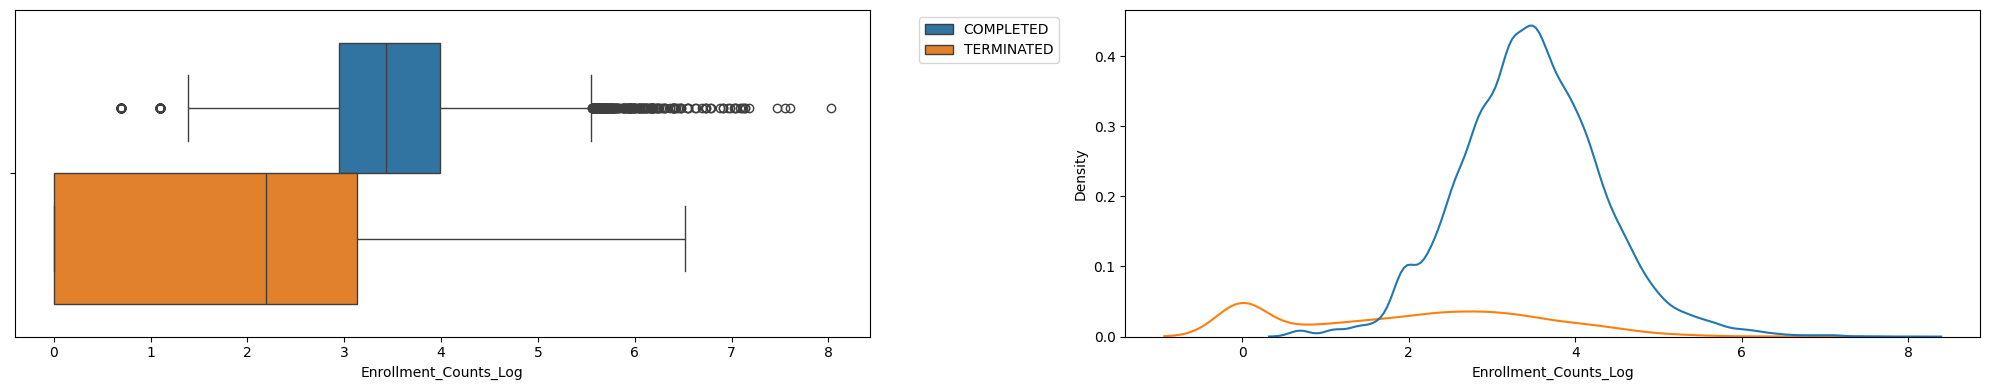

In [187]:
Enrollment_Counts_Log = log_fun_cont("Enrollment_Counts_Log", dfi, i)

Text(0.5, 0.98, 'Enrollment_Counts_Log Scatterplots by Phase')

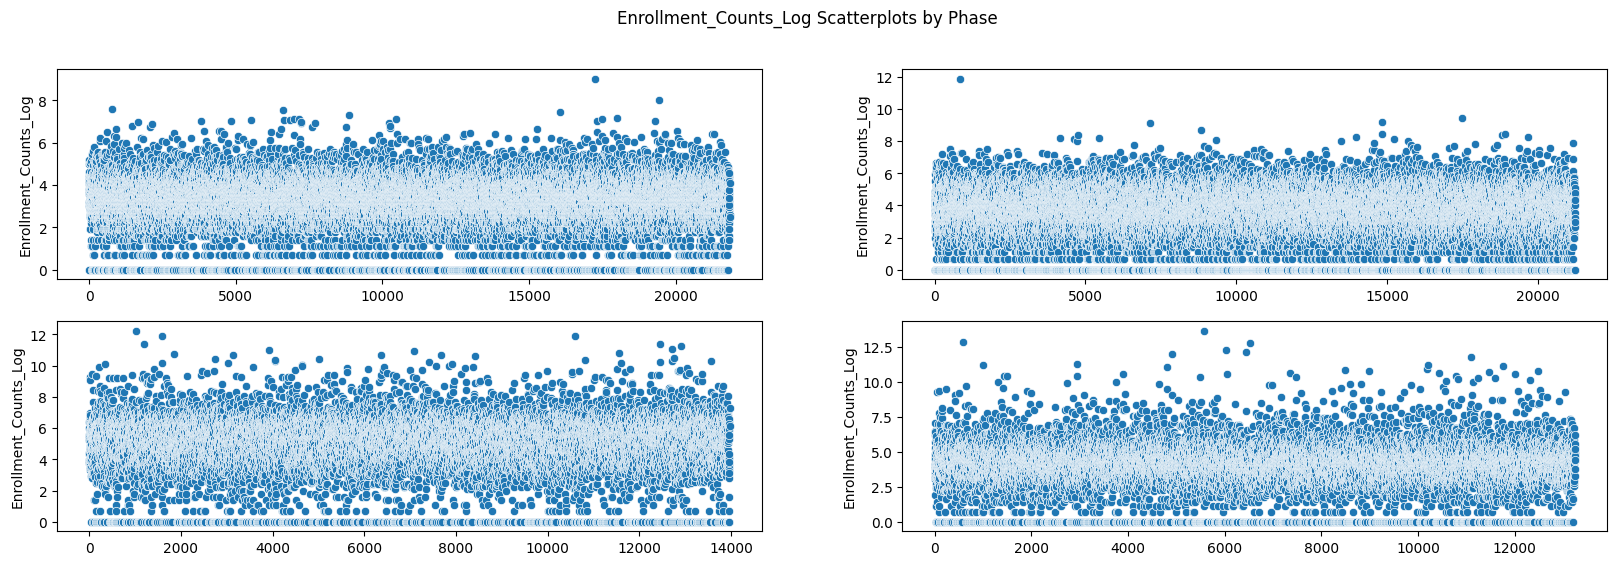

In [188]:
plt.fig, ax = plt.subplots(figsize=(20, 6), nrows = 2, ncols = 2)

sns.scatterplot(df1['Enrollment_Counts_Log'], ax=ax[0,0])
sns.scatterplot(df2['Enrollment_Counts_Log'], ax=ax[0,1])
sns.scatterplot(df3['Enrollment_Counts_Log'], ax=ax[1,0])
sns.scatterplot(df4['Enrollment_Counts_Log'], ax=ax[1,1])

plt.fig.suptitle('Enrollment_Counts_Log Scatterplots by Phase')

### Enrollment_Categ
- See Enrollment Plot as Continues below. Better Plot as continues (BoxPlot)

df1-Phase 1:
Enrollment_Categ vs Study Status

p-value: 1.613361843673847e-224 < 0.05

------------------------------------------------------------------------------------------------------------

df1-Phase 1:
Enrollment_Categ vs Study Status (Termination)



Study_Status_Bin          COMPLETED  TERMINATED
Enrollment_Categ 0–28          6905        2052
                 29–8231       8012         494

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17461
Method:                           MLE   Df Model:                            1
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                 0.07547
Time:                        04:51:26   Log-Likelihood:                -6705.8
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                4.573e-240
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -1.2134      0.025    -48.262      0.000      -1.263      -1.164
Enrollment_Categ    -1.5727      0.053    -29.821      0.000      -1.676      -1.469


df1-Phase1: Enrollment_Cat

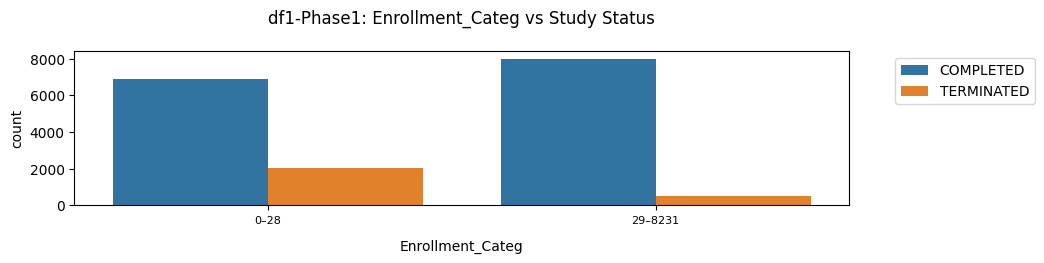

In [189]:
chi2_fun("Enrollment_Categ", dfi, i)
#### log_fun
Enrollment_Categ = log_fun('Enrollment_Categ', dfi, i, 'bin', True, 0)

#### Format

In [190]:
Enrollemnt_Counts_aic = fun_compare(i, Enrollment_Counts = Enrollment_Counts[0], 
                                    Enrollment_Counts_Log = Enrollment_Counts_Log[0]) 
                                    
Enrollemnt_Counts_aic

,Enrollment_Counts,Enrollment_Counts_Log,AIC_min
df1,,,
Enrollment_Counts,[13180.0],[10812.0],Enrollment_Counts_Log


In [191]:
#dfi = dfi.drop(columns = ['Enrollment_Counts', 'Enrollment_Categ'], axis = 1)

#### Enrollment Outliers

Text(0.5, 0.98, 'Phase 1 Enrollment_Counts_Log')

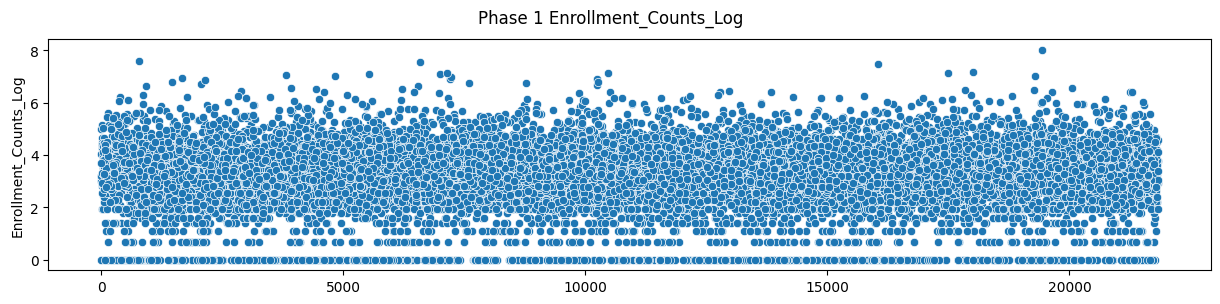

In [192]:
plt.fig, ax = plt.subplots(figsize=(15, 3))

sns.scatterplot(dfi['Enrollment_Counts_Log'],)

plt.fig.suptitle(f'Phase {i} Enrollment_Counts_Log')

# AIC

### Continuous

In [ ]:
aics = [
        Adverse_Counts_aic, Adverse_System_Counts_aic,
        Arm_Counts_aic,
        City_Counts_aic, Country_Counts_aic, Continent_Counts_aic, 
        Enrollemnt_Counts_aic,
        ]
for idx in range(len(aics)):
    aic = aics[idx]
    for col in aic.columns:
        if '_' in col:
            new_col = col.split('_')[-1]
            aic.rename(columns = {col: new_col}, inplace = True)
    aics[idx] = aic
# aics[-2] # Example

AIC_Total = pd.concat(aics, ignore_index = False)
AIC_Total = AIC_Total.rename(columns = {'min' : 'AIC_Min'})
AIC_Total = AIC_Total.reindex(labels = ['Counts', 'Log', 'Categ', 'Bin', 'AIC_Min'], axis = 1)
AIC_Total

### Categorical Format

In [195]:
display(Masking_aic, Adverse_aic)

,Masking_List,Masking_Detail_List,AIC_min
df1,,,
Masking_List,[14384.0],[14396.0],Masking_List


,Adverse_List,Adverse_System_List,AIC_min
df1,,,
Adverse_List,[14434.0],[14387.0],Adverse_System_List


# P_Value/ CL : Univariable 

In [ ]:
Masking_List

NameError: name 'Masking_Detail' is not defined


KeyboardInterrupt



In [ ]:
p_cols = dfi.columns.tolist()
# cls df
cl_vars = p_cols.copy()
cl_list = [globals()[var][2][1:] for var in cl_vars if var!= 'Study_Status_Bin']  
cls = pd.concat(cl_list, axis = 0).reset_index(drop = False)
cls = cls.rename(columns = {'index': f'Variable', 0: f'df{i}-Lower_CL', 1: f'df{i}-Upper_CL'})
cls[[f'df{i}-Lower_CL', f'df{i}-Upper_CL']] = cls[[f'df{i}-Lower_CL', f'df{i}-Upper_CL']].round(3)

# p_values df
p_vars = p_cols.copy()
p_list = [globals()[var][1][0][1:] for var in p_vars if var!= 'Study_Status_Bin']   
# [1][0][1:] Explain:
# [1] --> index = 1 of function's returns = p_value , 
# [0] --> gives back the unique element of list as a df, 
# [1:] --> excludes 1st row which is the constant.
p_values = pd.concat(p_list, axis = 0).reset_index(drop = False)
p_values = p_values.rename(columns = {'index': f'Variable', 0: f'df{i}-p-value'})
p_values[f'df{i}-p-value'] = p_values[f'df{i}-p-value'].round(3)

# p_cl df
p_cl = pd.merge(left = p_values, right = cls, how = 'inner', on = f'Variable')
p_cl[f'df{i}-Stat_Sig'] = np.where((p_cl[f'df{i}-p-value'] < 0.05), 'Stat_Sig', '-')

p_cl.index.name = f'df{i}'
p_cl = p_cl.drop_duplicates()
p_cl

# Pivots

In [ ]:
[col for col in dfi.columns if '_Categ' in col]

[]

In [ ]:
parameters = [Sex_List[3], Age_List[3],  
        Intervention_Type_List[3], Intervention_Route_List[3], 
        Conditions_Detail_List[3], Adverse_List[3], Adverse_System_List[3],
        Intervention_Model_List[3], 
        Masking_List[3], Masking_Detail_List[3], 
        Primary_Purpose_List[3], 
        Global_Bin[3], Continents_List[3],
        # Bin
        Funder_Industry_Bin[3], Placebo_Bin[3], Standard_Care_Bin[3],  Global_Bin[3], 
        Healthy_Bin[3], Covid_19_Bin[3], Adverse_Bin[3], Allocation_Bin[3],
        # Categ
        Enrollment_Categ[3], Arm_Categ[3], 
        Adverse_System_Categ[3], Intervention_Type_Categ[3], Intervention_Route_Categ[3],
        City_Categ[3], Continent_Categ[3], 
        Completion_Gap_Categ[3]]

pivots = pd.concat(parameters, axis= 0)
pivots.index.name = f'df{i}'
pivots = pivots.rename(columns = {'COMPLETED': f'df{i}_COMPLETED', 'TERMINATED': f'df{i}_TERMINATED'})
pivots

Study_Status_Bin             df1_COMPLETED  df1_TERMINATED
Sex_List             ALL             12088            2255
                     FEMALE            588             133
                     MALE             2241             158
Age_List             ADULT           14560            2462
                     CHILD             810             213
...                                    ...             ...
City_Categ           2–104            3576             919
Continent_Categ      0–1             14131            2273
                     2–6               786             273
Completion_Gap_Categ 0–11             8150             798
                     12–160           6767            1748

[123 rows x 2 columns]

# Save p_values

In [ ]:
def save_pvalue_pickle(p_cl, i):
    
    if i == 1:
        path = r".\p_values\p_cl1_vizual_train.pkl"
    elif i == 2:
        path = r".\p_values\p_cl2_vizual_train.pkl"
    elif i == 3:
        path = r".\p_values\p_cl3_vizual_train.pkl"
    elif i == 4:
        path = r".\p_values\p_cl4_vizual_train.pkl"

    return p_cl.to_pickle(path)

save_pvalue_pickle(p_cl, i)


# Save Pivots

In [ ]:
def save_pivots_pickle(pivots, i):
    
    if i == 1:
        path = r".\p_values\pivots1_vizual_train.pkl"
    elif i == 2:
        path = r".\p_values\pivots2_vizual_train.pkl"
    elif i == 3:
        path = r".\p_values\pivots3_vizual_train.pkl"
    elif i == 4:
        path = r".\p_values\pivots4_vizual_train.pkl"

    return pivots.to_pickle(path)

save_pivots_pickle(pivots, i)